# Multimodal MCI Diagnosis & Stability Prediction

**Thesis demonstration** — End-to-end inference pipeline for two real patients using all
pre-trained models: Chandra OCR, Mistral LLM, MRI 3D-CNN, PET 3D-CNN,
LightGBM diagnosis, neural ensemble diagnosis, RNN stability, LightGBM stability.

> **No training occurs in this notebook.** All weights are loaded from locally saved files.

## Environment Setup

Imports all required libraries and defines all file paths for models, images, and data files.
This cell must run first — every subsequent cell depends on these definitions.

In [1]:
import sys, warnings, pickle, os, json, re, time
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


BASE_DIR = Path("/kaggle/input/datasets/baraafzlalagui/demo-fyp-data-and-models/demo fyp")

# -- Model and image paths ------------------------------------------------
MRI_IMAGE_DIR = BASE_DIR / "mri" / "images"
MRI_FOLD_DIR  = BASE_DIR / "mri" / "models"

PET_IMAGE_DIR = BASE_DIR / "pet" / "images"
PET_FOLD_DIR  = BASE_DIR / "pet" / "models"

DIAG_ROOT = BASE_DIR / "diagnosis_alg"
STAB_ROOT = BASE_DIR / "stability_alg"

# -- PET age normalisation (training-set-wide statistics, not patient-specific) --
PET_AGE_MEAN = 75.072048
PET_AGE_STD  =  7.961197

# -- Demo patients --------------------------------------------------------
# mri_sub / pet_sub = None means that patient has no imaging scan
PATIENTS = [
    {"folder": str(BASE_DIR / "patients" / "patient_mci"),          "label": "Patient A",
     "mri_sub": "348321",  "pet_sub": "I225450"},
    {"folder": str(BASE_DIR / "patients" / "patient_mci_unstable"), "label": "Patient B",
     "mri_sub": None,        "pet_sub": None},
]

print("All paths configured.")

Device  : cuda
PyTorch : 2.10.0+cu128
All paths configured.


## Patient Reports — Scanned Handwritten Clinical Notes

Displays the raw scanned pages for each patient. These are the inputs to the OCR step.
Patient A's report is expected to reflect a stable MCI profile; Patient B's an unstable one.

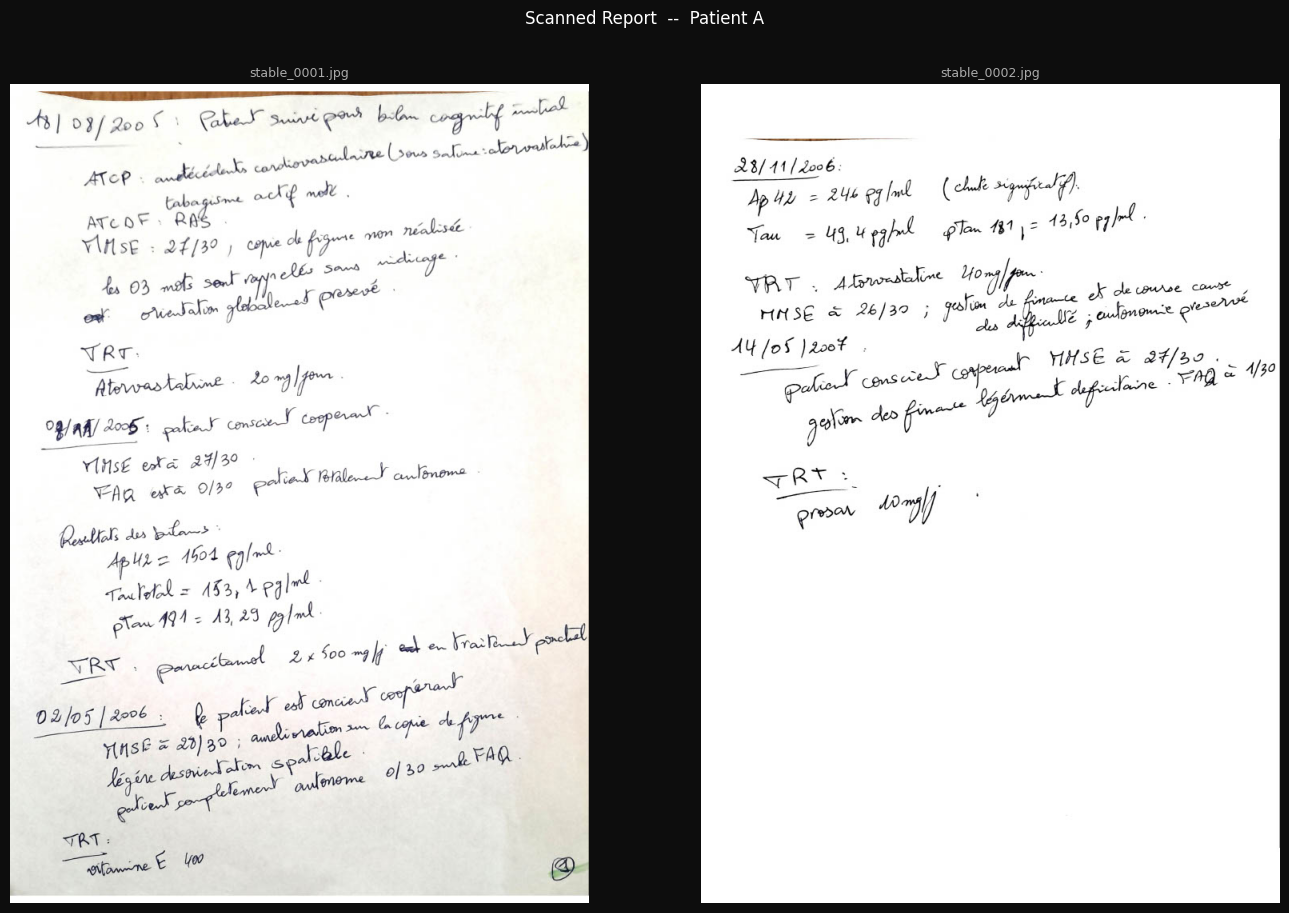

  Patient A: 2 page(s)  --  ['stable_0001.jpg', 'stable_0002.jpg']


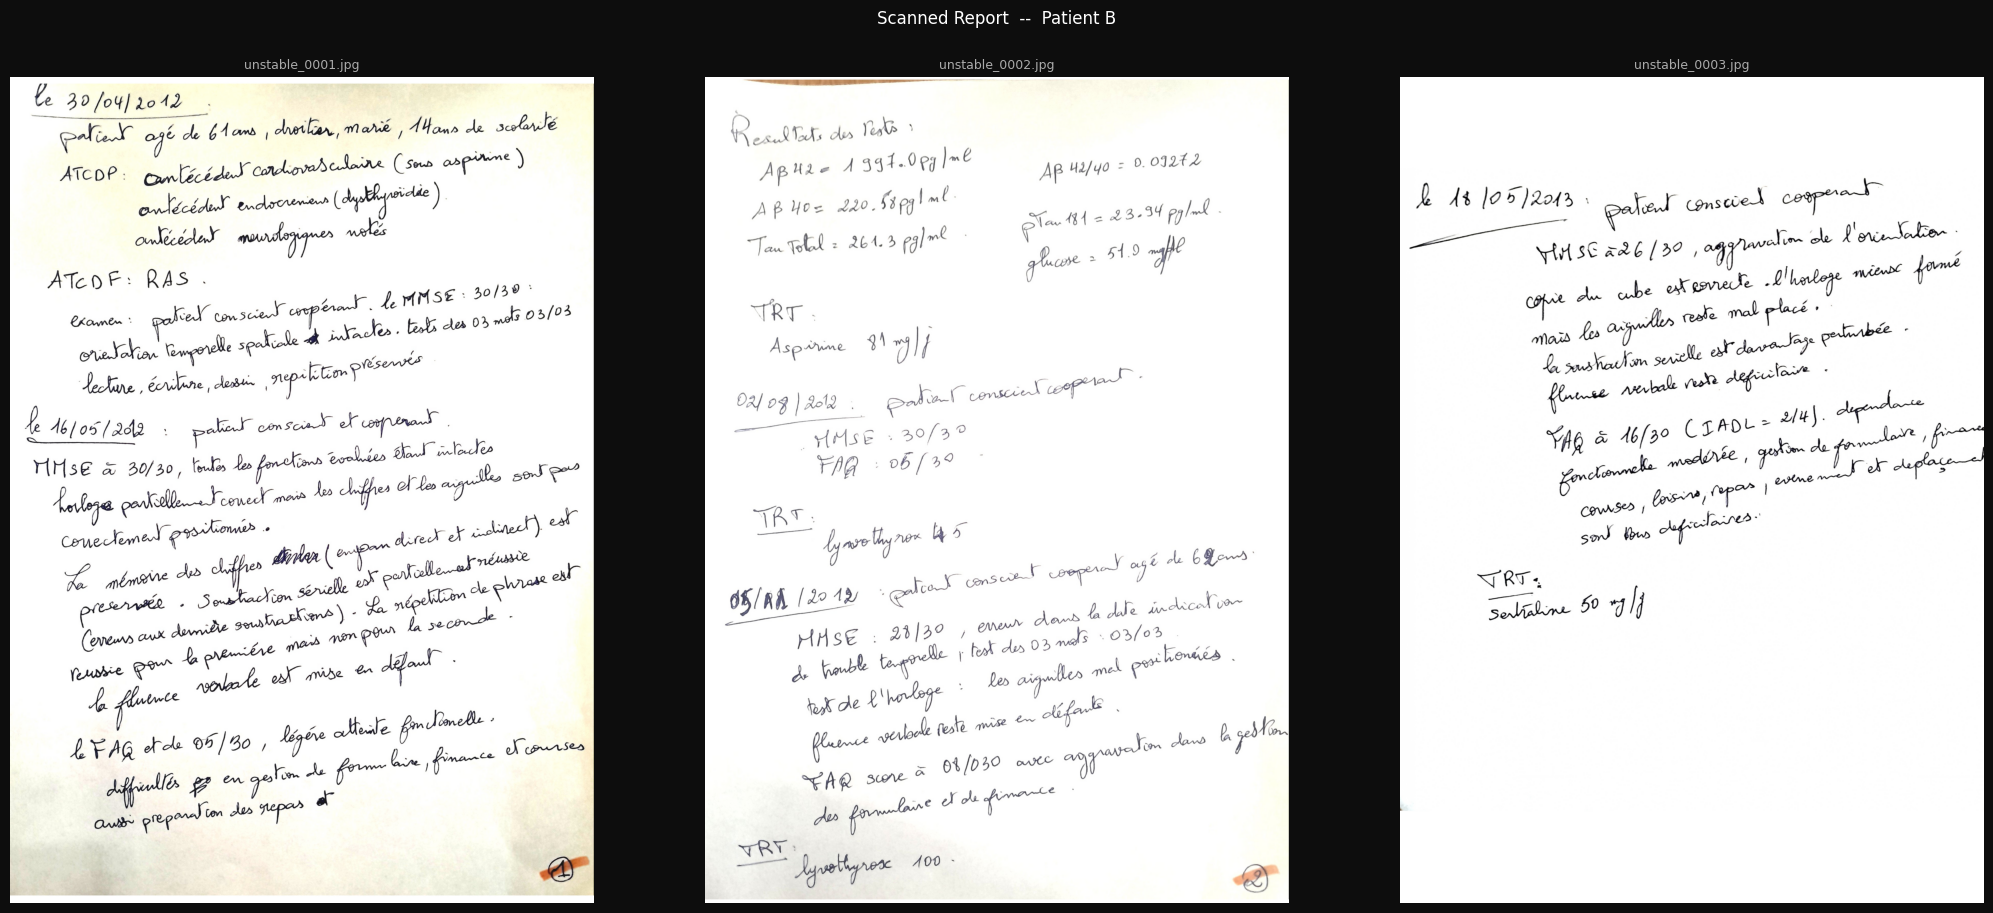

  Patient B: 3 page(s)  --  ['unstable_0001.jpg', 'unstable_0002.jpg', 'unstable_0003.jpg']


In [2]:
# Display the scanned handwritten clinical reports for each patient
for pat in PATIENTS:
    folder = pat["folder"]
    label  = pat["label"]
    pages  = sorted(
        [f for f in Path(folder).iterdir()
         if f.suffix.lower() in {".jpg", ".jpeg", ".png"}],
        key=lambda p: p.name,
    )
    n = len(pages)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 9), facecolor='#0d0d0d')
    if n == 1:
        axes = [axes]
    for ax, img_path in zip(axes, pages):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(img_path.name, color='#aaaaaa', fontsize=9, pad=6)
        ax.axis('off')
    fig.suptitle(f"Scanned Report  --  {label}", color='white', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"  {label}: {n} page(s)  --  {[p.name for p in pages]}")


## Step 1a — Install OCR Package

Installs `chandra-ocr` (Chandra VLM, `datalab-to/chandra-ocr-2`) and `pyspellchecker`.
On Kaggle, this runs once at session start. Safe to skip if already installed.

In [3]:
# ── Install Chandra OCR ───────────────────────────────────────────────────────
import subprocess, sys

print("Installing Chandra OCR (datalab-to/chandra-ocr-2) ...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "chandra-ocr[hf]"])
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyspellchecker"])

import torch
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch        : {torch.__version__}")


Installing Chandra OCR (datalab-to/chandra-ocr-2) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 102.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 61.8 MB/s eta 0:00:00
CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB
PyTorch        : 2.10.0+cu128


## Step 1b — Load Chandra OCR Model

Downloads and loads the Chandra vision-language model in `bfloat16` onto the GPU.
This model reads the handwritten scanned report pages and returns structured text.

In [ ]:
# ── Load Chandra OCR model ───────────────────────────────────────────────────
from transformers import AutoModelForImageTextToText, AutoProcessor
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown
from PIL import Image

print("Loading Chandra OCR on GPU (bfloat16)...")
chandra_model = AutoModelForImageTextToText.from_pretrained(
    "datalab-to/chandra-ocr-2",
    dtype=torch.bfloat16,
    device_map="auto",
)
chandra_model.eval()
chandra_model.processor = AutoProcessor.from_pretrained("datalab-to/chandra-ocr-2")
chandra_model.processor.tokenizer.padding_side = "left"

print("✓ Chandra OCR loaded")
if torch.cuda.is_available():
    print(f"  VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")


## Step 1c — OCR Inference Helpers

Defines `ocr_report(folder)` which iterates over all page images in a patient folder,
runs Chandra OCR on each, and concatenates the raw text output.
Also defines image loading and resizing utilities used by the OCR call.

In [ ]:
# -- Clinical report OCR helpers --
import re
from pathlib import Path

MAX_IMAGE_DIM = 1536
IMAGE_EXTS    = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}


def _natural_key(path: Path):
    return [int(tok) if tok.isdigit() else tok.lower()
            for tok in re.split(r'(\d+)', path.stem)]


def _list_report_pages(path: str) -> list:
    p = Path(path)
    if p.is_file():
        return [p]
    pages = sorted((f for f in p.iterdir() if f.suffix.lower() in IMAGE_EXTS),
                   key=_natural_key)
    if not pages:
        raise FileNotFoundError(f"No image files found in {p}")
    return pages


def _resize_for_chandra(img: Image.Image, max_dim: int = MAX_IMAGE_DIM) -> Image.Image:
    w, h = img.size
    longest = max(w, h)
    if longest <= max_dim:
        return img
    scale = max_dim / longest
    return img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.LANCZOS)


def _markdown_to_lines(raw_markdown: str) -> str:
    markdown = parse_markdown(raw_markdown)
    lines = []
    for line in markdown.splitlines():
        line = re.sub(r'^#+\s*', '', line.strip())
        line = re.sub(r'^[-*•]\s*', '', line)
        if line:
            lines.append(line)
    return ' '.join(lines)


def run_chandra_ocr(image_path) -> str:
    img = Image.open(image_path).convert("RGB")
    img = _resize_for_chandra(img)
    batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
    try:
        result = generate_hf(batch, chandra_model)[0]
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        img = _resize_for_chandra(img, max_dim=MAX_IMAGE_DIM // 2)
        batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
        result = generate_hf(batch, chandra_model)[0]
    return _markdown_to_lines(result.raw)


def ocr_report(folder: str) -> str:
    """Run Chandra OCR on all pages in folder, return concatenated raw text."""
    pages = _list_report_pages(folder)
    print(f"  Found {len(pages)} page(s): {[p.name for p in pages]}")
    texts = []
    for i, page_path in enumerate(pages, 1):
        print(f"  Page {i}/{len(pages)}: {page_path.name} ...", end=" ", flush=True)
        texts.append(run_chandra_ocr(page_path))
        print("done")
    return "\n".join(texts)


print("OCR helper functions defined.")

## Step 2 — OCR Text Post-Processing

Defines `postprocess_plain_text(text)` and its helpers:
abbreviation expansion (French medical abbreviations), date normalisation,
fuzzy matching against a medical vocabulary (medications, neurological terms, tests),
French spell-checking, and noise removal.
The cleaned text is the input to the LLM extraction step.

In [ ]:
# ── OCR post-processing pipeline (medical dictionaries + cleaning) ───────────
import re
from difflib import SequenceMatcher
from typing import List, Dict, Tuple

ABBREV_TXT = """alzheimer,alz,az,alzmr,alzr
ampoule,amp,ampl,emp,empl
ampoules,amps,ampls,emps,empls
année moyenne,am
année primaire,ap
année secondaire,as
antécédent,ancd,antcd,antc,atcd,atcs,atd,ant
antécédents familiaux,antcdf,antcf,antdf,atcdf,atdf,antf
antécédents personnels et familiaux,antfp,antcdfp,atcdfp,antcfp,antfp,antcdfp,atcdfp,antcfp,antpf,antfp
antécédents personnels,antcdp,antcp,antdp,atcdp,atdp,antp
athymil,athl
avec,ac
beaucoup,BCP
biologique,bio
cholestrol,CHOL
cm,cmcomportement,cmpt,cmprt,cmprtmn,cpt,comport,compt,cprt,cpt
comprimé,CP
conduite à tenir,cat
consultation,cons
cortico sous cortical,csc
cérébrale,cereb,cerl,crl
dans,dn,dns
diabète de type 2,dnid
diagnostic,diag
droite,drt,drte
décédé,dcd
examen,ex,exm,exmn
familiaux,f
fns,fns
fois par jour,xj,x/j
fois,x
gauche,gche,gch
glucose,glu
glycémie,gly
goutte,gtt,gtte
gouttes,gtts,gttes
grand,gd
histoire de la maladie,hdm
hypertension artérielle,hta
indiçage,indice,indiçe
insuffisance rénale,ir
jour,jr,j
léger,lg
malade,mld,md,madie
maladie d’Alzheimer,ma
maladie,mde,mdie
mautif de consultation,mc
mnésique,mnes,mnsq
modéré,mod
mémoire,mem,mmr
même,mm
neurologique,neuro
neuropsychologie,neuropsy
niveau intellectuel,ni
niveau,niv
normal,nml
par jour,/j
pendant,pdt
personels,p
pour,pr
présente,pste
psychologue,psycho,psy
quelque,qlq,qqs
rendez-vous,rdv
rien à signaler,ras
sous traitement,s/trt
sous,s,s/
stable,stbl
stade,std
système nerveux central,snc
sévère,sev,svr
tdm cérébrale,tdmc
temps,tp
test,tst
tm,tm
traitement,trt,trtm,trtmn
trouble cognitif,tc
trouble neurocognitif,tnc
troubles,trbl,tbl,tb,trb,tbls,tbs,trbs,trbls
vitamine E,vite
vitamine,vit"""

MEDICATIONS_TXT = """Aricept
aspirine
Aspégic
atacond
Athymil
Aténor
B
Deroxat
Digoxine
donecept
donépézil
Dépakine
E
Ebixa
Exelon
Furosémide
gabatrex
galantamine
Glucophage
Largactil
levocarb
Lévothyrox
mag
micardis
mémantine
Risperdal
rivastigmine
rowasa
synosia
Tensoprel
tolvon
vitamag
vitamine
zoloft"""

TERMS_TXT = """aggravation
agitation
agnosie
agraphie
agressivité
alexie
alzheimer
amimique
amnésie
ampoule
antécédent
antérograde
aphasie
apraxie
artérielle
atrophie
attention
audiovisuel
auditif
bilan
biologique
blanche
cardiopathie
cerveau
clonique
cognitif
comportement
comprimé
compréhension
concentration
confusion
conscience
conscient
consultationcoopérant
cortex
cérébral
diabète
dyslipidémie
dysthyroïdie
déficie
dégradation
démence
démentiel
dépendance
dépressif
dépression
désinvestissement
désorientation
détérioration
encéphalopathie
eeg
ecg
examen
fonction
frontal
gestuel
goutte
hippocampe
hippocampique
hydrocéphalie
hypertension
hypothyroïdie
imagerie
incohérent
indifférence
insomniaque
insomnie
instabilité
insuffisance
intellectuel
IRM
irritabilité
irritabilité
isolement
langage
leucoaraïose
lobe
léger
légèrement
lésion
mg
majeur
malade
maladie
mixte
ml
mmhg
mnésique
modéré
mémoire
neurocognitif
neurodégénérative
neurologique
neuropsychologique
ng
niveau
nécessitant
orientation
orienté
oublis
pariétal
patient
persécution
progressif
prédominance
prédominant
présente
préservé
psychiatrique
psychologique
psychologue
rendez-vous
rigidité
rénal
scanner
sommeil
spatiale
spontanément
spychiatre
stabilisation
stade
stationnaire
substance
syndrome
sévère
TDM
temporal
temporel
temporospatiale
tendance
traitement
troubles
vasculaire
ventricule
épilepsie
épisodique
évaluation
évolution"""

TESTS_TXT = """MMSE
MoCA
l'horloge
IADL
PSMS
ADL
GDS"""


def _load_abbreviations(raw: str) -> Dict[str, str]:
    d = {}
    for line in raw.strip().splitlines():
        line = line.strip()
        if not line or ',' not in line:
            continue
        parts = [p.strip().lower() for p in line.split(',')]
        for variant in parts[1:]:
            d[variant] = parts[0]
    return d


def _load_list(raw: str) -> List[str]:
    return [line.strip().lower() for line in raw.strip().splitlines() if line.strip()]


abbreviations = _load_abbreviations(ABBREV_TXT)
medications   = _load_list(MEDICATIONS_TXT)
terms         = _load_list(TERMS_TXT)
tests         = _load_list(TESTS_TXT)
print(f"Loaded {len(abbreviations)} abbreviations, {len(medications)} medications, "
      f"{len(terms)} terms, {len(tests)} tests")


def split_mixed_words(text: str) -> str:
    text = re.sub(r'(\d+)([a-zàâäéèêëïîôöœçñ]+)', r'\1 \2', text, flags=re.IGNORECASE)
    text = re.sub(r'([a-zàâäéèêëïîôöœçñ]+)(\d+)', r'\1 \2', text, flags=re.IGNORECASE)
    return text


def normalize_dates(text: str) -> str:
    pattern = r'(\d{1,2})\s*[/:\-.\'\s](\d{1,2})\s*[/:\-.\'\s](\d{2,4})'
    def _rep(m):
        day, month, year = m.group(1).zfill(2), m.group(2).zfill(2), m.group(3)
        if len(year) == 2:
            year = '20' + year
        return f"{day}/{month}/{year}\n"
    return re.sub(pattern, _rep, text)


def replace_abbreviations(text: str, abbrev_dict: Dict[str, str]) -> Tuple[str, set]:
    words = text.split()
    result, corrected_indices = [], set()
    for i, word in enumerate(words):
        word_clean = re.sub(r"[^\w'/]", '', word.lower())
        if word_clean in abbrev_dict:
            result.append(abbrev_dict[word_clean])
            corrected_indices.add(i)
        else:
            result.append(word)
    return ' '.join(result), corrected_indices


def find_closest_match(word: str, reference_list: List[str], threshold: float = 0.75) -> Tuple[str, bool]:
    word_lower = word.lower()
    if word_lower in reference_list:
        return word_lower, True
    best_match, best_ratio = None, threshold
    for ref in reference_list:
        ratio = SequenceMatcher(None, word_lower, ref).ratio()
        if ratio > best_ratio:
            best_ratio, best_match = ratio, ref
    return (best_match, True) if best_match else (word, False)


def apply_fuzzy_matching(text: str, medications: List[str], terms: List[str], tests: List[str]) -> Tuple[str, set]:
    words = text.split()
    result, corrected_indices = [], set()
    for i, word in enumerate(words):
        m, ok = find_closest_match(word, medications, 0.75)
        if ok: result.append(m); corrected_indices.add(i); continue
        m, ok = find_closest_match(word, terms, 0.75)
        if ok: result.append(m); corrected_indices.add(i); continue
        m, ok = find_closest_match(word, tests, 0.75)
        if ok: result.append(m); corrected_indices.add(i); continue
        result.append(word)
    return ' '.join(result), corrected_indices


def correct_french_spelling(text: str, skip_indices: set = None,
                             reference_lists: List[List[str]] = None) -> str:
    if skip_indices is None:
        skip_indices = set()
    if reference_lists is None:
        reference_lists = []
    reference_words = {w.lower() for lst in reference_lists for w in lst}
    try:
        from spellchecker import SpellChecker
        spell = SpellChecker(language='fr')
        words = text.split()
        corrected = []
        for i, word in enumerate(words):
            if i in skip_indices:
                corrected.append(word); continue
            word_lower = word.lower()
            word_clean = re.sub(r'[^\w]', '', word_lower)
            if word_clean in reference_words:
                corrected.append(word); continue
            if not re.search(r'[a-zàâäéèêëïîôöœçñ]', word, re.IGNORECASE):
                corrected.append(word); continue
            if word_clean not in spell:
                closest = spell.correction(word_clean)
                corrected.append(closest if closest else word)
            else:
                corrected.append(word)
        return ' '.join(corrected)
    except ImportError:
        return text


def clean_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()


def remove_noise(text: str, noise_patterns: List[str]) -> str:
    for pat in noise_patterns:
        try:
            text = re.sub(pat, '', text, flags=re.IGNORECASE)
        except re.error:
            text = text.replace(pat, '')
    return re.sub(r'\s+', ' ', text).strip()


NOISE_PATTERNS = ['MouMNi', 'Moumni', 'moumni']


def postprocess_plain_text(raw_text: str) -> str:
    text = split_mixed_words(raw_text)
    text = normalize_dates(text)
    text, abbrev_idx = replace_abbreviations(text, abbreviations)
    text, fuzzy_idx  = apply_fuzzy_matching(text, medications, terms, tests)
    text = correct_french_spelling(
        text,
        skip_indices=abbrev_idx | fuzzy_idx,
        reference_lists=[medications, tests, ['CM', 'TM', 'ro']],
    )
    text = remove_noise(text, NOISE_PATTERNS)
    text = clean_text(text)
    return text



print("OCR post-processing pipeline defined.")

## Step 3a — Install Mistral Client

Installs the `mistralai` Python package. Required to call the Mistral Large API.
On Kaggle, add your `MISTRAL_API_KEY` under Settings > Add-ons > Secrets.

In [ ]:
# ── Install Mistral client ────────────────────────────────────────────────────
!pip install -q mistralai
print("mistralai ready.")

## Step 3b — LLM Feature Extraction: ADNI Table Builder

Defines the full extraction pipeline that converts cleaned French clinical text
into the 135-column ADNI tabular format:

- **`TARGET_COLUMNS`**: the 135 ADNI fields to extract
- **`CODEBOOK`**: complete data dictionary with ADNI categorical encodings
- **`SYSTEM_PROMPT`**: strict extraction rules sent to Mistral Large
- **`call_mistral(text)`**: sends the cleaned report to `mistral-large-latest`
  with `temperature=0` and `response_format=json_object`, returns a Python dict.

Also loads the Mistral client using `MISTRAL_API_KEY` from the environment.

In [ ]:
# ── Mistral API setup ─────────────────────────────────────────────────────────
import os, json, re, time
from mistralai.client import Mistral

mistral_client = Mistral(api_key="i0LQlpZ3sFHFUHTUecMpZgPd21MbOrXV")


# ── Target columns ─────────────────────────────────────────────────────────────
TARGET_COLUMNS = [
    # Patient demographics
    "age", "PTGENDER", "PTEDUCAT", "PTHAND", "PTMARRY", "PTNOTRT", "PTWORK",
    # MMSE sub-items
    "MMDATE","MMYEAR","MMMONTH","MMDAY",
    "MMREAD","MMWRITE","MMDRAW","MMREPEAT",
    "MMSEASON","MMHOSPIT","MMFLOOR","MMCITY",
    "WORD1","WORD2","WORD3","MMSCORE",
    # MoCA / Clock
    "MOCA","CUBE","CLOCKCON","CLOCKNO","CLOCKHAN",
    # Digit span / Serial 7 / Repetition / Fluency
    "DIGFOR","DIGBACK",
    "SERIAL1","SERIAL2","SERIAL3","SERIAL4","SERIAL5",
    "REPEAT1","REPEAT2","FFLUENCY",
    # FAQ
    "FAQFORM","FAQFINAN","FAQSHOP","FAQGAME","FAQBEVG",
    "FAQMEAL","FAQEVENT","FAQTV","FAQREM","FAQTRAVL","FAQ",
    # Blood biomarkers (available in Algerian clinical setting)
    "Abeta42","Abeta40","Abeta_ratio",
    "Tau181","pTau181",
    "Calcium","Creatinine","Direct Bilirubin",
    "Gamma-Glutamyltransferase",
    "Hematocrit","Hemoglobin","Hemoglobin A1C",
    "Homocysteine",
    "Platelet Ct.","Red Blood Cell Count",
    "Thyroid-stimulating hormone","Total Bilirubin",
    "Vitamin B12","White Blood Cell Count",
    "glucose",
    # Family history
    "MOTHDEM","MOTHAD","MOTHSXAGE",
    "FATHDEM","FATHAD","FATHSXAGE",
    "SIBGENDER","SIBDEMENT","SIBAD","SIBSXAGE",
    # Intercurrent illness
    "IHSYMPTOM","IHDESC","IHCHRON","IHSEVER","IHPRESENT","IHSURG",
    # Medical history flags
    "MH19OTHR","MHPSYCH","MH2NEURL","MH3HEAD","MH4CARD",
    "MH5RESP","MH6HEPAT","MH7DERM","MH8MUSCL","MH9ENDO",
    "MH14BALCH","MH14CALCH","MH10GAST","MH11HEMA","MH12RENA",
    "MH13ALLE","MH14ALCH","MH14AALCH","MH17MALI","MH18SURG",
    # Substance history
    "MH15DRUG","MH15ADRUG","MH15BDRUG",
    "MH16SMOK","MH16ASMOK","MH16BSMOK","MH16CSMOK",
    # Behavioural symptoms
    "BSXSYMNO","BSXSEVER","BSXCHRON",
    # Medication
    "KEYMED","CMMED","CMDOSE","CMREASON",
]

# ── ADNI codebook ──────────────────────────────────────────────────────────────
CODEBOOK = """
=== ADNI COLUMN CODEBOOK WITH ENCODINGS ===

--- PATIENT DEMOGRAPHICS ---
age      : patient age at visit (numeric, years, e.g. 76.0)
PTGENDER : sex -- 1=Male, 2=Female
PTEDUCAT : years of education completed (numeric, integer, e.g. 16)
PTHAND   : handedness -- 1=Right, 2=Left, 3=Ambidextrous; null if not stated
PTMARRY  : marital status -- 1=Married, 2=Widowed, 3=Divorced, 4=Never married, 5=Unknown
PTNOTRT  : not receiving any cognitive/AD treatment -- 0=No (is on treatment), 1=Yes (no treatment); null if not stated
PTWORK   : employment status -- 1=Employed full-time, 2=Employed part-time, 3=Self-employed, 4=Retired, 5=Homemaker, 6=Disabled, 7=Unemployed, 8=Student; null if not stated

--- MMSE SUB-ITEMS ---
Each item: 0 = incorrect / not done, 1 = correct, null = not tested
MMDATE   : day of month correct
MMYEAR   : year correct
MMMONTH  : month correct
MMDAY    : day of week correct
MMREAD   : reads "close your eyes" and closes eyes
MMWRITE  : writes a complete sentence
MMDRAW   : copies intersecting pentagons
MMREPEAT : repeats "no ifs, ands, or buts"
MMSEASON : season correct
MMHOSPIT : hospital / place name correct
MMFLOOR  : floor number correct
MMCITY   : city correct
WORD1    : recall of first word (0/1)
WORD2    : recall of second word (0/1)
WORD3    : recall of third word (0/1)
MMSCORE  : total MMSE (0-30, integer)

--- MoCA / CLOCK ---
MOCA     : total MoCA score (0-30); null if not administered
CUBE     : 3-D cube copy correct (0/1)
CLOCKCON : clock contour correct (0/1)
CLOCKNO  : clock numbers correct (0/1)
CLOCKHAN : clock hands correct (0/1)

--- DIGIT SPAN ---
DIGFOR   : forward digit span correct (0/1)
DIGBACK  : backward digit span correct (0/1)

--- SERIAL 7 (five subtractions, each 0=wrong 1=right) ---
SERIAL1  : first subtraction (100-7=93) correct (0/1)
SERIAL2  : second subtraction (93-7=86) correct (0/1)
SERIAL3  : third subtraction (86-7=79) correct (0/1)
SERIAL4  : fourth subtraction (79-7=72) correct (0/1)
SERIAL5  : fifth subtraction (72-7=65) correct (0/1)

--- PHRASE REPETITION ---
REPEAT1  : first phrase correct (0/1)
REPEAT2  : second phrase correct (0/1)

--- VERBAL FLUENCY ---
FFLUENCY : letter fluency correct (0/1)

--- FAQ ITEMS ---
Scale: 0=normal, 1=has difficulty but does alone, 2=needs assistance, 3=dependent/unable
FAQFORM  : managing bills and financial documents
FAQFINAN : managing bank accounts / finances
FAQSHOP  : shopping alone for food and clothes
FAQGAME  : playing games requiring skill (cards, puzzles, chess)
FAQBEVG  : heating water and making hot drinks
FAQMEAL  : preparing a balanced meal
FAQEVENT : keeping track of current events (news)
FAQTV    : paying attention to / understanding TV, books, magazines
FAQREM   : remembering appointments and medications
FAQTRAVL : travelling out of the neighbourhood alone
FAQ      : total FAQ score (sum of all 10 items, 0-30)

--- BIOMARKERS (numeric, null if not measured) ---
Abeta42, Abeta40, Abeta_ratio : amyloid-beta peptides (pg/mL)
Tau181, pTau181 : tau phosphorylation markers (pg/mL)
Calcium, Creatinine, Direct Bilirubin : metabolic panel
Gamma-Glutamyltransferase : liver/alcohol marker
Hematocrit, Hemoglobin, Hemoglobin A1C : haematology / glycaemia
Homocysteine : cardiovascular risk marker (µmol/L)
Platelet Ct., Red Blood Cell Count, White Blood Cell Count : complete blood count
Thyroid-stimulating hormone (TSH) : thyroid function
Total Bilirubin, Vitamin B12 : labs
glucose : blood glucose (mg/dL)

--- FAMILY HISTORY ---
MOTHDEM  : 0=no, 1=yes (mother had dementia)
MOTHAD   : 0=no, 1=yes (mother had Alzheimer's)
MOTHSXAGE: age of mother at symptom onset (numeric, null if unknown)
FATHDEM  : 0=no, 1=yes (father had dementia)
FATHAD   : 0=no, 1=yes (father had Alzheimer's)
FATHSXAGE: age of father at symptom onset (numeric, null if unknown)
SIBGENDER: gender of affected sibling -- 1=Male, 2=Female, null if no affected sibling
SIBDEMENT: 0=no, 1=yes (sibling had dementia)
SIBAD    : 0=no, 1=yes (sibling had Alzheimer's)
SIBSXAGE : age of sibling at symptom onset (numeric, null if unknown)

--- INTERCURRENT ILLNESS ---
IHSYMPTOM: category of illness symptom (integer code):
    1=Psychiatric, 2=Neurologic (other than cognitive),
    3=Head/Eyes/Ears/Nose/Throat, 4=Cardiovascular, 5=Respiratory,
    6=Hepatic, 7=Dermatologic, 8=Musculoskeletal, 9=Endocrine-Metabolic,
    10=Gastrointestinal, 11=Hematopoietic-Lymphatic, 12=Renal-Genitourinary,
    13=Allergies/Drug Sensitivities, 14=Smoking/Alcohol/Drug Use,
    17=Malignancy, 18=Other, 19=Cognitive Disorder/Symptom
    -> null if no intercurrent illness
IHDESC   : free-text description of the illness (string or null)
IHCHRON  : 0=no, 1=yes (illness is chronic)
IHSEVER  : severity -- 1=mild, 2=moderate, 3=severe; null if no illness
IHPRESENT: 0=no, 1=yes (illness still present at visit)
IHSURG   : 0=no, 1=yes (required surgery)

--- MEDICAL HISTORY FLAGS (0=absent, 1=present) ---
MH19OTHR : other conditions not listed elsewhere
MHPSYCH  : psychiatric history (depression, anxiety, bipolar, etc.)
MH2NEURL : neurological history (stroke, epilepsy, Parkinson's, etc.)
MH3HEAD  : head/eyes/ears/nose/throat history
MH4CARD  : cardiovascular history (hypertension, angina, MI, arrhythmia, etc.)
MH5RESP  : respiratory history (asthma, COPD, etc.)
MH6HEPAT : hepatic history (hepatitis, cirrhosis, etc.)
MH7DERM  : dermatological / connective tissue history
MH8MUSCL : musculoskeletal history (arthritis, osteoporosis, etc.)
MH9ENDO  : endocrine history (diabetes, thyroid disease, etc.)
MH14BALCH: history of binge alcohol use (0/1)
MH14CALCH: current alcohol use (0/1)
MH10GAST : gastrointestinal history (ulcer, IBD, etc.)
MH11HEMA : haematological history (anaemia, coagulopathy, etc.)
MH12RENA : renal history (CKD, nephrolithiasis, etc.)
MH13ALLE : allergy / drug sensitivity history (0/1)
MH14ALCH : general alcohol use history (0/1)
MH14AALCH: age at first alcohol use (numeric, null if none)
MH17MALI : malignancy / cancer history (0/1)
MH18SURG : prior surgery history (0/1)

--- SUBSTANCE HISTORY ---
MH15DRUG : illicit drug use history -- 0=no, 1=yes
MH15ADRUG: drug name(s) (free text, null if none)
MH15BDRUG: frequency of drug use (free text, null if none)
MH16SMOK : smoking history -- 0=never, 1=former smoker, 2=current smoker
MH16ASMOK: age started smoking (numeric, null if never smoked)
MH16BSMOK: age stopped smoking (numeric, null if current or never)
MH16CSMOK: packs per day (numeric, null if never)

--- BEHAVIOURAL SYMPTOMS ---
BSXSYMNO : symptom type code (integer, null if none):
    1=Nausea, 2=Vomiting, 3=Diarrhea, 4=Constipation,
    5=Abdominal discomfort, 6=Sweating, 7=Dizziness, 8=Low energy,
    9=Drowsiness, 10=Blurred vision, 11=Headache, 12=Dry mouth,
    13=Shortness of breath, 14=Coughing, 15=Palpitations,
    16=Chest pain, 17=Urinary discomfort, 18=Urinary frequency,
    19=Ankle swelling, 20=Musculoskeletal pain, 21=Rash,
    22=Insomnia, 23=Depressed mood, 24=Crying, 25=Elevated mood,
    26=Wandering, 27=Fall, 28=Other
    -> null if no behavioural symptom
BSXSEVER : severity -- 1=mild, 2=moderate, 3=severe; null if no symptom
BSXCHRON : duration in months (numeric); null if no symptom

--- MEDICATION ---
KEYMED   : key cognitive medication code (integer):
    0=None of the above,
    1=Aricept (donepezil),
    3=Exelon (rivastigmine),
    4=Namenda (memantine),
    5=Razadyne (galantamine),
    6=Anti-depressant medication,
    7=Other behavioural medication
    -> null if no cognitive medication mentioned
CMMED    : concomitant medication name (free text, e.g. "Atorvastatin")
CMDOSE   : dose (free text, e.g. "20mg", "400 IU")
CMREASON : reason for medication (integer):
    1=Adverse Event,
    2=Therapeutic Use,
    3=Prophylaxis / Non-therapeutic Use
    -> null if not determinable
"""

# ── System prompt ──────────────────────────────────────────────────────────────
SYSTEM_PROMPT = f"""You are a clinical data extraction assistant specialised in the ADNI dataset.
You receive a French medical report describing ONE patient visit.

Your task: extract values for EXACTLY the columns listed at the end and return ONLY a valid JSON object.

STRICT RULES:
1. Use JSON null for any value not mentioned or not determinable from the text.
2. Binary flags (0/1): use 1 if clearly present/positive, 0 if clearly absent, null if unknown.
3. Numeric scores: return as JSON numbers (e.g. 30, not "30/30").
4. For FAQ items: use the 0-3 scale defined in the codebook. Compute FAQ total as the sum of the 10 items.
5. Categorical columns: use the INTEGER code defined in the codebook (e.g. KEYMED=1 for Aricept, not "Aricept").
6. Text fields (CMMED, CMDOSE, IHDESC, MH15ADRUG, MH15BDRUG): return a string or null.
7. CMREASON: derive from context -- therapeutic use for chronic disease=2, prophylaxis=3, side effect=1.
8. KEYMED: donepezil/Aricept=1, rivastigmine/Exelon=3, memantine/Namenda=4, galantamine/Razadyne=5,
   antidepressant=6, other behavioural=7, none=0, null if no cognitive medication mentioned.
9. MH16SMOK: 0=never smoked, 1=former smoker, 2=current smoker.
10. SIBGENDER: 1=Male sibling, 2=Female sibling, null if no affected sibling.
11. IHSYMPTOM: use the integer category code from the codebook, null if no intercurrent illness.
12. BSXSYMNO: use the integer code from the codebook, null if no behavioural symptom.
13. Never add keys not in the target list. Never add text outside the JSON.

{CODEBOOK}

Columns to extract (return ALL, even if null):
{json.dumps(TARGET_COLUMNS, ensure_ascii=False)}
"""


def build_user_prompt(text: str) -> str:
    return (
        "Patient visit report (French):\n"
        "---\n"
        f"{text}\n"
        "---\n"
        "Extract the ADNI values and return a single JSON object."
    )


def call_mistral(text: str, retries: int = 3) -> dict:
    for attempt in range(retries):
        try:
            response = mistral_client.chat.complete(
                model="mistral-large-latest",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": build_user_prompt(text)},
                ],
                temperature=0.0,
                response_format={"type": "json_object"},
            )
            raw = response.choices[0].message.content.strip()
            raw = re.sub(r'^```(?:json)?\s*', '', raw)
            raw = re.sub(r'\s*```$', '', raw)
            return json.loads(raw)
        except Exception as e:
            print(f"  [attempt {attempt + 1}] Error: {e}")
            if attempt < retries - 1:
                time.sleep(3)
    return {}



print("Mistral client and helpers defined.")

## Step 4a — MRI Model Architecture

Defines `Small3DCNNDemo`, the 3D convolutional architecture trained to detect
medial temporal atrophy (MTA) from preprocessed T1-weighted MRI volumes.
The model fuses a demographic branch (age, sex, education) with the CNN backbone.
`CHANNEL_CONFIGS` maps the fold-specific channel keys from the saved checkpoints.

In [ ]:
# ── MRI model architecture (must match training) ─────────────────────────────
class Small3DCNNDemo(nn.Module):
    def __init__(self, n_demo_features=3, demo_hidden=16,
                 n_targets=1, dropout=0.3, channels=(16, 32, 64, 128)):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm3d(out_c), nn.ReLU(inplace=True), nn.MaxPool3d(2))
        layers = [block(1, channels[0])]
        for i in range(len(channels) - 1):
            layers.append(block(channels[i], channels[i + 1]))
        self.backbone     = nn.Sequential(*layers)
        self.global_pool  = nn.AdaptiveAvgPool3d(1)
        self.demo_encoder = nn.Sequential(
            nn.Linear(n_demo_features, demo_hidden), nn.ReLU(inplace=True),
            nn.Linear(demo_hidden, demo_hidden),     nn.ReLU(inplace=True))
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(channels[-1] + demo_hidden, n_targets)

    def forward(self, x, demo):
        feat = self.global_pool(self.backbone(x)).flatten(1)
        d    = self.demo_encoder(demo)
        return self.head(self.dropout(torch.cat([feat, d], dim=1))).squeeze(1)

CHANNEL_CONFIGS = {
    "narrow_3":   (8,  16,  32),
    "narrow_4":   (8,  16,  32,  64),
    "standard_4": (16, 32,  64, 128),
    "wide_4":     (32, 64, 128, 256),
}
print("Small3DCNNDemo architecture loaded.")


## Step 4b — MRI 7-Fold Ensemble Inference

Defines `infer_mri(volume, subject_id)` which runs the 7-fold cross-validation
ensemble. For each fold it loads the per-fold scaler and config from `fold_k.pkl`,
reconstructs the model, and runs a forward pass. The final atrophy decision is
the average probability across all 7 folds compared to the average threshold.

In [ ]:
# -- MRI 7-fold ensemble inference function --
def infer_mri(mri_vol: np.ndarray, age: float, gender: float, edu: float):
    """Run the 7-fold MRI atrophy ensemble. Returns (atrophy_flag, avg_prob, avg_thr).
    gender: 1.0=Male, 0.0=Female  (training convention)
    """
    x = torch.from_numpy(mri_vol[None, None]).to(DEVICE)
    probs, thrs = [], []
    for k in range(7):
        with open(MRI_FOLD_DIR / f"fold_{k}.pkl", "rb") as f:
            res = pickle.load(f)
        sc  = res["demo_scaler"]
        cfg = res["config"]
        thr = res["test_results"]["threshold"]
        age_z = (age - sc["age_mean"]) / sc["age_std"]
        edu_z = (edu - sc["edu_mean"]) / sc["edu_std"]
        demo  = torch.tensor([[gender, age_z, edu_z]], dtype=torch.float32).to(DEVICE)
        m = Small3DCNNDemo(channels=CHANNEL_CONFIGS[cfg["channels_key"]],
                           demo_hidden=cfg["demo_hidden"], dropout=cfg["dropout"]).to(DEVICE)
        m.load_state_dict(torch.load(MRI_FOLD_DIR / f"fold_{k}_best_model.pt",
                                     map_location=DEVICE, weights_only=True))
        m.eval()
        with torch.no_grad():
            p = torch.sigmoid(m(x, demo)).item()
        probs.append(p)
        thrs.append(thr)
        del m
    avg = float(np.mean(probs))
    thr_avg = float(np.mean(thrs))
    return int(avg >= thr_avg), avg, thr_avg


print("MRI inference function defined.")

## Step 5a — PET Model Architecture

Defines `Simple3DCNN_LateFusion`, the 3D CNN for amyloid PET binary classification.
A late-fusion demographic branch (age, sex) is concatenated with the CNN features
before the final classification head. `PET_CFG` holds the exact hyperparameters
used at training time and stored in the saved checkpoint files.

In [11]:
# ── PET model architecture (must match training) ─────────────────────────────
class Simple3DCNN_LateFusion(nn.Module):
    def __init__(self, channels=(32,64,128,256), fc_units=128,
                 dropout=0.3, kernel_size=3, demo_hidden=16):
        super().__init__()
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks += [nn.Conv3d(in_ch, out_ch, kernel_size, padding=kernel_size//2, bias=False),
                       nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True), nn.MaxPool3d(2)]
            in_ch = out_ch
        self.encoder     = nn.Sequential(*blocks)
        self.gap         = nn.AdaptiveAvgPool3d(1)
        self.demo_branch = nn.Sequential(nn.Linear(2, demo_hidden), nn.ReLU())
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(in_ch + demo_hidden, fc_units)
        self.head        = nn.Linear(fc_units, 2)

    def forward(self, img, demo):
        x = self.gap(self.encoder(img)).flatten(1)
        x = self.dropout(torch.cat([x, self.demo_branch(demo)], dim=1))
        return self.head(F.relu(self.fc(x)))

PET_CFG = {"channels": (32, 64, 128, 256), "kernel_size": 3,
           "fc_units": 128, "dropout": 0.3, "demo_hidden": 16}
print("Simple3DCNN_LateFusion architecture loaded.")


Simple3DCNN_LateFusion architecture loaded.


## Step 5b — PET 7-Fold Ensemble Inference

Defines `infer_pet(volume, subject_id)` which runs the 7-fold amyloid PET ensemble.
Each fold checkpoint stores the best classification threshold; the final decision
averages probabilities and thresholds across all 7 folds.

In [12]:
# -- PET 7-fold ensemble inference function --
def infer_pet(pet_vol: np.ndarray, age: float, sex_f: float):
    """Run the 7-fold PET amyloid ensemble. Returns (amyloid_flag, avg_prob, avg_thr).
    sex_f: 1.0=Female, 0.0=Male  (training convention)
    """
    age_z = (age - PET_AGE_MEAN) / PET_AGE_STD
    demo  = torch.tensor([[age_z, sex_f]], dtype=torch.float32).to(DEVICE)
    x     = torch.from_numpy(pet_vol).unsqueeze(0).unsqueeze(0).to(DEVICE)
    probs, thrs = [], []
    for k in range(7):
        ckpt = torch.load(PET_FOLD_DIR / f"fold_{k}.pt", map_location=DEVICE, weights_only=False)
        m = Simple3DCNN_LateFusion(**PET_CFG).to(DEVICE)
        m.load_state_dict(ckpt["state_dict"])
        m.eval()
        with torch.no_grad():
            p = torch.softmax(m(x, demo), dim=1)[0, 1].item()
        probs.append(p)
        thrs.append(ckpt["best_threshold"])
        del m
    avg = float(np.mean(probs))
    thr_avg = float(np.mean(thrs))
    return int(avg >= thr_avg), avg, thr_avg


print("PET inference function defined.")

PET inference function defined.


## Step 6 — Patient Record Integration

Defines `build_patient_record(llm_features, mri_atrophy, amyloid_status)` which
merges the structured clinical features extracted by Mistral with the two imaging
biomarkers (`MTA_ATROPHY`, `AMYLOID_STATUS`) into a single visit dictionary.
This unified record is the input to both the diagnosis and stability classifiers.

In [13]:
# -- Patient record helpers --
def _fmt(v):
    return "N/A" if v is None else str(v)


def build_patient_record(features_from_ocr: dict,
                          mri_atrophy: int, amyloid_status: int) -> dict:
    record = dict(features_from_ocr)
    record["MTA_ATROPHY"]    = mri_atrophy
    record["AMYLOID_STATUS"] = amyloid_status
    return record


def print_record_summary(patient_record: dict,
                          mri_atrophy: int, amyloid_status: int) -> None:
    summary = {
        "Age":              patient_record.get("age"),
        "Sex":              patient_record.get("PTGENDER"),
        "Education (yr)":   patient_record.get("PTEDUCAT"),
        "MMSE":             patient_record.get("MMSCORE"),
        "MoCA":             patient_record.get("MOCA"),
        "FAQ":              patient_record.get("FAQ"),
        "HTA / Cardio":     patient_record.get("MH4CARD"),
        "Diabetes / Endo":  patient_record.get("MH9ENDO"),
        "Psychiatric Hx":   patient_record.get("MHPSYCH"),
        "Family dem. (Mo)": patient_record.get("MOTHDEM"),
        "Medication":       patient_record.get("CMMED"),
        "MRI Atrophy":      "YES (MTA=1)" if mri_atrophy else "NO  (MTA=0)",
        "Amyloid PET":      "POSITIVE (1)" if amyloid_status else "NEGATIVE (0)",
    }
    for k, v in summary.items():
        try:
            abnormal = (
                (k == "MMSE"        and v is not None and float(v) < 24) or
                (k == "MoCA"        and v is not None and float(v) < 26) or
                (k == "FAQ"         and v is not None and float(v) > 5)  or
                (k == "MRI Atrophy" and "YES" in str(v))                 or
                (k == "Amyloid PET" and "POSITIVE" in str(v))
            )
        except (TypeError, ValueError):
            abnormal = False
        flag = " <- ABNORMAL" if abnormal else ""
        print(f"  {k:22s}: {_fmt(v)}{flag}")


print("Patient record helpers defined.")

Patient record helpers defined.


## Step 7a — Load Diagnosis Model Artifacts

Loads all pre-trained diagnosis classifier artifacts from the local model directory:
scaler, label encoder, feature columns, global medians for imputation,
string encoders for categorical features, the LightGBM model, and the ensemble
weights for the three-model neural soft-vote.

In [14]:
# -- Load all diagnosis classifier artifacts from local model directory --
diag_arts = {
    "scaler":           joblib.load(DIAG_ROOT / "scaler.pkl"),
    "label_encoder":    joblib.load(DIAG_ROOT / "label_encoder.pkl"),
    "feature_cols":     joblib.load(DIAG_ROOT / "feature_cols.pkl"),
    "global_medians":   joblib.load(DIAG_ROOT / "global_medians.pkl"),
    "string_encoders":  joblib.load(DIAG_ROOT / "string_encoders.pkl"),
    "lightgbm":         joblib.load(DIAG_ROOT / "lightgbm.pkl"),
    "ensemble_weights": joblib.load(DIAG_ROOT / "ensemble_weights.pkl"),
}

DIAG_LABELS = {0: "CN", 1: "Dementia", 2: "MCI"}

print(f"Diagnosis artifacts loaded.")
print(f"  Feature columns : {len(diag_arts['feature_cols'])}")
print(f"  Ensemble members: {list(diag_arts['ensemble_weights'].keys())}")
print(f"  Classes         : {list(diag_arts['label_encoder'].classes_)}")


Diagnosis artifacts loaded.
  Feature columns : 222
  Ensemble members: ['GRNNet', 'DeepResNet-SE', 'DualStreamDomainNet']
  Classes         : [np.int64(0), np.int64(1), np.int64(2)]


## Step 7b — Neural Ensemble: Architectures and Weights

Defines the three neural classifiers used in the diagnosis ensemble:

- **GRNNet** (Gated Residual Network, 5 blocks, hidden=256)
- **DeepResNet-SE** (6 residual blocks with squeeze-excitation, hidden=256)
- **DualStreamDomainNet** (domain-grouped dual-stream + multi-head attention)

Loads saved weights (`*_state.pt`) for all three models and defines
`predict_diag_ensemble()` which performs weighted soft-vote across them.

In [15]:
# -- Neural ensemble: architecture definitions + model loading --

# --- GRNNet ---
class GRNBlock(nn.Module):
    def __init__(self, in_d, hidden_d, out_d, dropout=0.2):
        super().__init__()
        self.fc1  = nn.Linear(in_d, hidden_d); self.fc2 = nn.Linear(hidden_d, out_d)
        self.fc3  = nn.Linear(in_d, out_d, bias=False)
        self.gate = nn.Linear(in_d, out_d)
        self.bn   = nn.BatchNorm1d(out_d); self.drop = nn.Dropout(dropout)
        self.skip = nn.Linear(in_d, out_d, bias=False) if in_d != out_d else nn.Identity()
    def forward(self, x):
        h = F.elu(self.fc1(x)); h = self.drop(h)
        h = self.fc2(h) + self.fc3(x)
        g = torch.sigmoid(self.gate(x))
        return self.bn(g * h + (1 - g) * self.skip(x))

class GRNNet(nn.Module):
    def __init__(self, n_features, hidden=256, n_blocks=5, dropout=0.25, proj_dim=64, n_out=3):
        super().__init__()
        self.entry  = nn.Sequential(nn.Linear(n_features, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.blocks     = nn.ModuleList([GRNBlock(hidden, hidden*2, hidden,
                                                   max(0.05, dropout - i*0.03)) for i in range(n_blocks)])
        self.projector  = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, proj_dim))
        self.head       = nn.Sequential(nn.Linear(hidden, 64), nn.LayerNorm(64), nn.GELU(),
                                        nn.Dropout(dropout*0.5), nn.Linear(64, n_out))
    def forward(self, x):
        x = self.entry(x)
        for b in self.blocks: x = b(x)
        return self.head(x)

# --- DeepResNet-SE ---
class SEBlock(nn.Module):
    def __init__(self, dim, reduction=4):
        super().__init__()
        self.se = nn.Sequential(nn.Linear(dim, dim//reduction), nn.ReLU(),
                                 nn.Linear(dim//reduction, dim), nn.Sigmoid())
    def forward(self, x): return x * self.se(x)

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim*2), nn.BatchNorm1d(dim*2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*2, dim), nn.BatchNorm1d(dim))
        self.se  = SEBlock(dim); self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.se(self.block(x)))

class DeepResNet(nn.Module):
    def __init__(self, n_features, hidden=256, n_blocks=6, dropout=0.25, proj_dim=64, n_out=3):
        super().__init__()
        self.entry  = nn.Sequential(nn.Linear(n_features, hidden), nn.BatchNorm1d(hidden), nn.GELU())
        self.blocks    = nn.ModuleList([ResBlock(hidden, max(0.05, dropout - i*0.025))
                                        for i in range(n_blocks)])
        self.projector = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, proj_dim))
        self.head      = nn.Sequential(nn.Linear(hidden, 64), nn.LayerNorm(64), nn.GELU(),
                                       nn.Dropout(dropout*0.4), nn.Linear(64, n_out))
    def forward(self, x):
        x = self.entry(x)
        for b in self.blocks: x = b(x)
        return self.head(x)

# --- DualStreamDomainNet ---
class DualStreamBranch(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.25):
        super().__init__()
        wide_d    = out_dim * 3
        self.wide = nn.Sequential(
            nn.Linear(in_dim, wide_d), nn.BatchNorm1d(wide_d), nn.GELU(),
            nn.Dropout(dropout*0.5), nn.Linear(wide_d, out_dim), nn.BatchNorm1d(out_dim))
        self.entry = nn.Linear(in_dim, out_dim)
        self.res1  = nn.Sequential(nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(),
                                   nn.Dropout(dropout), nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim))
        self.res2  = nn.Sequential(nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(),
                                   nn.Dropout(dropout*0.6), nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim))
        self.act      = nn.GELU()
        self.gate_in  = nn.Sequential(nn.Linear(in_dim, in_dim), nn.Sigmoid())
        self.fuse     = nn.Sequential(nn.Linear(out_dim*2, out_dim), nn.Sigmoid())
    def forward(self, x):
        xg = x * self.gate_in(x); hw = self.wide(xg)
        hd = self.act(self.entry(xg)); hd = self.act(hd + self.res1(hd)); hd = self.act(hd + self.res2(hd))
        alpha = self.fuse(torch.cat([hw, hd], dim=1))
        return alpha * hw + (1 - alpha) * hd

class DualStreamDomainNet(nn.Module):
    def __init__(self, domain_indices, branch_dim=64, n_heads=4, dropout=0.25, proj_dim=64, n_out=3):
        super().__init__()
        self.idx      = domain_indices
        self.branches = nn.ModuleDict({n: DualStreamBranch(len(ids), branch_dim, dropout)
                                        for n, ids in domain_indices.items()})
        self.norm1 = nn.LayerNorm(branch_dim)
        self.attn  = nn.MultiheadAttention(branch_dim, n_heads, dropout=0.1, batch_first=True)
        self.norm2 = nn.LayerNorm(branch_dim)
        self.ff    = nn.Sequential(nn.Linear(branch_dim, branch_dim*2), nn.GELU(),
                                   nn.Dropout(0.1), nn.Linear(branch_dim*2, branch_dim))
        pool_dim       = branch_dim * 2
        self.projector = nn.Sequential(nn.Linear(pool_dim, pool_dim), nn.GELU(), nn.Linear(pool_dim, proj_dim))
        self.head      = nn.Sequential(nn.Linear(pool_dim, 128), nn.LayerNorm(128), nn.GELU(),
                                       nn.Dropout(dropout*0.5),
                                       nn.Linear(128, 64), nn.GELU(), nn.Dropout(dropout*0.2),
                                       nn.Linear(64, n_out))
    def _pool(self, x):
        outs = [self.branches[n](x[:, self.idx[n]]) for n in self.branches]
        h    = torch.stack(outs, dim=1)
        h    = h + self.attn(self.norm1(h), self.norm1(h), self.norm1(h))[0]
        h    = h + self.ff(self.norm2(h))
        return torch.cat([h.mean(1), h.max(1).values], dim=1)
    def forward(self, x): return self.head(self._pool(x))


# --- Domain index builder ---
def _build_group_map(feature_cols):
    cog = [c for c in feature_cols if any(x in c for x in
        ['MMDATE','MMYEAR','MMMONTH','MMDAY','MMREAD','MMWRITE','MMDRAW','MMREPEAT',
         'MMSEASON','MMHOSPIT','MMFLOOR','MMCITY','WORD','MMSCORE','CUBE','CLOCK',
         'DIGFOR','DIGBACK','SERIAL','REPEAT','FFLUENCY','MOCA'])]
    fnc = [c for c in feature_cols if 'FAQ' in c]
    bio = [c for c in feature_cols if any(x in c for x in
        ['Abeta','Tau','pTau','Calcium','Creatinine','Glucose','Hemoglobin',
         'Thyroid','Vitamin','Homocysteine','Cystatin','Bilirubin','Urea',
         'Phosphatase','Transferase','Hematocrit','Methylmalonic','Lactate',
         'Platelet','Red Blood','White Blood','eGFR','glucose','protein',
         'Alanine','Aspartate','Gamma-Glutamyl','High Sensitivity',
         'AMYLOID_STATUS','MTA_ATROPHY'])]
    dem = [c for c in feature_cols if any(x in c for x in
        ['PTGENDER','age','PTHAND','PTMARRY','PTEDUCAT','PTWORK','PTNOTRT',
         'MOTHDEM','MOTHAD','FATHDEM','FATHAD','SIBGENDER','SIBDEMENT','SIBAD'])]
    mh  = [c for c in feature_cols if c.startswith('MH') or
           any(x in c for x in ['IHSYMPTOM','IHDESC','IHCHRON','IHSEVER','IHPRESENT','IHSURG',
                                 'KEYMED','BSXSYMNO','CMMED','CMDOSE','CMREASON'])]
    assigned = set(cog + fnc + bio + dem + mh)
    other    = [c for c in feature_cols if c not in assigned]
    return {'cognitive': cog, 'functional': fnc, 'biomarker': bio,
            'demographic': dem, 'medical_history': mh, 'other': other}

def _build_idx(all_feat, group_map):
    idx = {}
    feat_set = set(all_feat)
    for g, cols in group_map.items():
        cs = set(cols)
        idx[g] = [i for i, c in enumerate(all_feat) if c in cs]
    for c in all_feat:
        if c.endswith('_missing'):
            base = c[:-len('_missing')]
            for g, cols in group_map.items():
                if base in set(cols):
                    pos = all_feat.index(c) if c in feat_set else -1
                    if pos >= 0: idx[g].append(pos)
                    break
    return {g: sorted(set(v)) for g, v in idx.items() if v}


# --- Load neural ensemble models ---
_feat_list   = list(diag_arts["feature_cols"])
_n_feat      = len(_feat_list)
_gm          = _build_group_map(_feat_list)
_domain_idx  = _build_idx(_feat_list, _gm)
_N_CLS       = len(DIAG_LABELS)

diag_neural_models = {}

_m = GRNNet(_n_feat, hidden=256, n_blocks=5, dropout=0.25, n_out=_N_CLS).to(DEVICE)
_m.load_state_dict(torch.load(DIAG_ROOT / "grnnet_state.pt",
                               map_location=DEVICE, weights_only=True))
_m.eval(); diag_neural_models["GRNNet"] = _m

_m = DeepResNet(_n_feat, hidden=256, n_blocks=6, dropout=0.25, n_out=_N_CLS).to(DEVICE)
_m.load_state_dict(torch.load(DIAG_ROOT / "deepresnet_se_state.pt",
                               map_location=DEVICE, weights_only=True))
_m.eval(); diag_neural_models["DeepResNet-SE"] = _m

_m = DualStreamDomainNet(_domain_idx, branch_dim=64, n_heads=4, dropout=0.25, n_out=_N_CLS).to(DEVICE)
_m.load_state_dict(torch.load(DIAG_ROOT / "dualstreamdomainnet_state.pt",
                               map_location=DEVICE, weights_only=True))
_m.eval(); diag_neural_models["DualStreamDomainNet"] = _m

print(f"Neural ensemble loaded: {list(diag_neural_models.keys())}")
ew = diag_arts["ensemble_weights"]
print(f"  Weights: { {k: round(v, 3) for k, v in ew.items()} }")


def predict_diag_ensemble(instance_dict, arts, neural_models):
    """Soft-vote ensemble of GRNNet + DeepResNet-SE + DualStreamDomainNet."""
    X  = preprocess_instance(instance_dict, arts)
    Xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    ew = arts["ensemble_weights"]
    probs = np.zeros(_N_CLS, dtype=np.float32)
    for name, w in ew.items():
        m = neural_models[name]
        m.eval()
        with torch.no_grad():
            p = F.softmax(m(Xt), dim=1).cpu().numpy()[0]
        probs += w * p
    pred = int(np.argmax(probs))
    return {
        "prediction":       DIAG_LABELS[pred],
        "class_index":      pred,
        "probabilities":    {DIAG_LABELS[i]: float(p) for i, p in enumerate(probs)},
        "ensemble_members": list(ew.keys()),
    }

print("predict_diag_ensemble defined.")


Neural ensemble loaded: ['GRNNet', 'DeepResNet-SE', 'DualStreamDomainNet']
  Weights: {'GRNNet': 0.335, 'DeepResNet-SE': 0.334, 'DualStreamDomainNet': 0.331}
predict_diag_ensemble defined.


## Step 7c — Diagnosis Inference Helpers

Defines the preprocessing function `preprocess_instance(record, arts)` that maps
a raw patient dict to the scaled feature vector expected by the models,
and `predict_diagnosis(record, arts)` which runs LightGBM inference and returns
the predicted class with per-class probabilities.

In [16]:
# ── Preprocessing + inference helpers ────────────────────────────────────────
def preprocess_instance(instance_dict, arts):
    feat_cols = arts["feature_cols"]
    glb_med   = arts["global_medians"]
    str_enc   = arts["string_encoders"]
    scaler    = arts["scaler"]
    row = {}
    for col in feat_cols:
        if col.endswith("_missing"):
            base = col[:-len("_missing")]
            row[col] = 1.0 if (base not in instance_dict or
                                pd.isna(instance_dict.get(base, np.nan))) else 0.0
        elif col in str_enc:
            val = str(instance_dict.get(col, "not_recorded"))
            le  = str_enc[col]
            val = val if val in le.classes_ else le.classes_[0]
            row[col] = float(le.transform([val])[0])
        else:
            val = instance_dict.get(col, np.nan)
            row[col] = float(glb_med.get(col, 0.0)) if pd.isna(val) else float(val)
    X_raw = np.array([[row[c] for c in feat_cols]], dtype=np.float32)
    return scaler.transform(X_raw).astype(np.float32)


def predict_diagnosis(instance_dict, arts):
    X     = preprocess_instance(instance_dict, arts)
    probs = arts["lightgbm"].predict_proba(X)[0]
    pred  = int(np.argmax(probs))
    return {"prediction": DIAG_LABELS[pred],
            "class_index": pred,
            "probabilities": {DIAG_LABELS[i]: float(p) for i, p in enumerate(probs)}}



print("Diagnosis inference helpers defined.")

Diagnosis inference helpers defined.


## Step 8a — Stability Model Architecture

Defines `RecurrentClassifier`: a stacked residual RNN with temporal attention.
Each `ResidualRNNBlock` applies a single-layer RNN with a residual projection
and LayerNorm. `TemporalAttention` pools the hidden states into a fixed-size
context vector for the final classification head.
This architecture was trained on PCA-reduced domain-grouped ADNI longitudinal sequences.

In [17]:
# ── Stability model architecture (must match training exactly) ───────────────
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hs, lengths):
        B, T, H = hs.shape
        scores = self.attn(hs).squeeze(-1)
        mask   = torch.arange(T, device=hs.device).unsqueeze(0) < lengths.unsqueeze(1)
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        return (weights * hs).sum(dim=1), weights.squeeze(-1)


class ResidualRNNBlock(nn.Module):
    def __init__(self, cell_type, input_size, hidden_size, dropout=0.0):
        super().__init__()
        RNNClass = {"rnn": nn.RNN, "gru": nn.GRU, "lstm": nn.LSTM}[cell_type.lower()]
        self.rnn  = RNNClass(input_size, hidden_size, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_size)
        self.proj = nn.Linear(input_size, hidden_size) if input_size != hidden_size else nn.Identity()

    def forward(self, x, hx=None):
        out, hx_new = self.rnn(x, hx)
        return self.norm(self.drop(out) + self.proj(x)), hx_new


class RecurrentClassifier(nn.Module):
    def __init__(self, input_size, num_classes, cell_type="rnn",
                 hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.blocks     = nn.ModuleList([
            ResidualRNNBlock(cell_type, hidden_size, hidden_size, dropout)
            for _ in range(num_layers)])
        self.attention  = TemporalAttention(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_size // 2, num_classes))

    def forward(self, x, lengths):
        h = self.input_proj(x)
        for blk in self.blocks:
            h, _ = blk(h)
        ctx, _ = self.attention(h, lengths)
        return self.classifier(ctx)

print("RecurrentClassifier architecture loaded.")


RecurrentClassifier architecture loaded.


## Step 8b — Load Stability Model Artifacts

Loads all pre-trained stability classifier artifacts: PCA reducers,
normalisation stats, feature columns, label encoder, categorical encoders,
global means for imputation, the RNN config and weights, the stability LightGBM model,
and the LightGBM trajectory feature column list.

In [18]:
# -- Load all stability classifier artifacts from local model directory --
stab_arts = {
    "pca_reducers":  joblib.load(STAB_ROOT / "pca_reducers.pkl"),
    "norm_stats":    joblib.load(STAB_ROOT / "rnn_norm_stats.pkl"),
    "feature_cols":  joblib.load(STAB_ROOT / "feature_cols.pkl"),
    "label_encoder": joblib.load(STAB_ROOT / "label_encoder.pkl"),
    "cat_encoders":  joblib.load(STAB_ROOT / "cat_encoders.pkl"),
    "global_means":  joblib.load(STAB_ROOT / "global_means.pkl"),
    "model_config":  joblib.load(STAB_ROOT / "rnn_config.pkl"),
    "lightgbm":      joblib.load(STAB_ROOT / "lightgbm.pkl"),
    "lgb_feat_cols": joblib.load(STAB_ROOT / "lgb_feature_cols.pkl"),
    "static_cols":   joblib.load(STAB_ROOT / "static_cols.pkl"),
}

cfg_stab   = stab_arts["model_config"]
stab_model = RecurrentClassifier(
    input_size   = cfg_stab["input_size"],
    num_classes  = cfg_stab["num_classes"],
    cell_type    = cfg_stab["cell_type"],
    hidden_size  = cfg_stab["hidden_size"],
    num_layers   = cfg_stab["num_layers"],
    dropout      = cfg_stab["dropout"],
).to(DEVICE)
stab_model.load_state_dict(
    torch.load(STAB_ROOT / "rnn_cfg2_domain_pca.pt", map_location=DEVICE, weights_only=True))
stab_model.eval()

print(f"Stability artifacts loaded.")
print(f"  RNN    : input={cfg_stab['input_size']}  hidden={cfg_stab['hidden_size']}"
      f"  layers={cfg_stab['num_layers']}  cell={cfg_stab['cell_type']}")
print(f"  LightGBM: {len(stab_arts['lgb_feat_cols'])} trajectory features")
print(f"  Classes : {list(stab_arts['label_encoder'].classes_)}")


Stability artifacts loaded.
  RNN    : input=36  hidden=128  layers=3  cell=rnn
  LightGBM: 315 trajectory features
  Classes : ['CN', 'MCI_converting', 'MCI_stable']


## Step 8c — Stability Inference Helpers

Defines inference functions for both stability classifiers:

- **`predict_stability(visits, arts, model)`** — RNN path: applies domain-wise PCA,
  normalises, pads to a sequence tensor, runs the recurrent classifier.
- **`predict_stab_lightgbm(visits, arts)`** — LightGBM path: computes trajectory
  summary statistics (slope, AUC, first/last/min/max/std, cumulative decline)
  for each of 21 longitudinal features, then runs the saved LightGBM model.

In [19]:
# -- Stability inference helpers (RNN + LightGBM) --
from scipy.stats import linregress

TRAJECTORY_COLS = [
    "MMSCORE","MOCA","FFLUENCY","DIGFOR","DIGBACK","CUBE","CLOCKCON","CLOCKNO","CLOCKHAN",
    "FAQ","FAQFORM","FAQFINAN","FAQMEAL","FAQEVENT",
    "Abeta42","Abeta40","Abeta_ratio","Tau181","pTau181",
    "AMYLOID_STATUS","MTA_ATROPHY",
]

STATIC_FEATURES = [
    "PTGENDER","age","PTHAND","PTMARRY","PTEDUCAT","PTWORK","PTNOTRT",
    "MOTHDEM","MOTHAD","FATHDEM","FATHAD","SIBGENDER","SIBDEMENT","SIBAD",
    "MH2NEURL","MH4CARD","MH9ENDO","MH16SMOK",
]


def _trapz(y, x):
    try:
        return np.trapz(y, x)
    except AttributeError:
        return float(np.sum(np.diff(x) * (y[:-1] + y[1:]) / 2.0))


# ---- RNN preprocessing + inference ----

def preprocess_visits_for_inference(visit_list, arts):
    """Convert visit list to PCA-reduced (1, T, D) tensor for RNN."""
    feat_cols    = arts["feature_cols"]
    cat_enc      = arts["cat_encoders"]
    gm           = arts["global_means"]
    mu, std      = arts["norm_stats"]["mu"], arts["norm_stats"]["std"]
    pca_red      = arts["pca_reducers"]

    rows = []
    for visit in visit_list:
        row = []
        for col in feat_cols:
            if col in cat_enc:
                val = str(visit.get(col, "UNKNOWN"))
                le  = cat_enc[col]
                val = val if val in le.classes_ else le.classes_[0]
                row.append(float(le.transform([val])[0]))
            elif col.endswith("_missing"):
                base = col[:-len("_missing")]
                row.append(1.0 if base not in visit or pd.isna(visit.get(base, np.nan)) else 0.0)
            elif col.endswith("_delta"):
                row.append(0.0)
            else:
                val = visit.get(col, np.nan)
                row.append(float(gm.get(col, 0.0)) if pd.isna(val) else float(val))
        rows.append(row)

    X_raw  = np.array(rows, dtype=np.float32)
    X_norm = np.nan_to_num((X_raw - mu) / std, nan=0.0)

    parts = []
    for domain, red in pca_red.items():
        idxs = [i for i in red["indices"] if i < X_norm.shape[1]]
        if idxs:
            parts.append(red["pca"].transform(X_norm[:, idxs]))
    X_pca = np.hstack(parts).astype(np.float32)
    return torch.tensor(X_pca).unsqueeze(0), torch.tensor([len(visit_list)], dtype=torch.long)


def predict_stability(visit_list, arts, model):
    """Run RNN stability prediction."""
    model.eval()
    X, lengths = preprocess_visits_for_inference(visit_list, arts)
    X = X.to(DEVICE); lengths = lengths.to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(X, lengths), dim=1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    le    = arts["label_encoder"]
    return {"prediction":    le.classes_[pred],
            "probabilities": {le.classes_[i]: float(p) for i, p in enumerate(probs)},
            "n_visits":      len(visit_list)}


# ---- LightGBM trajectory summary + inference ----

def _compute_stab_traj_summary(visit_list, arts):
    """Build trajectory summary feature vector for the stability LightGBM."""
    cat_enc      = arts["cat_encoders"]
    global_means = arts["global_means"]
    feat_cols    = arts["feature_cols"]
    lgb_feat     = arts["lgb_feat_cols"]

    rows = []
    for v_idx, visit in enumerate(visit_list):
        row = {"_month": visit.get("_month", v_idx * 12)}
        for col in feat_cols:
            if col.endswith(("_delta", "_rate", "_from_bl", "_missing")):
                continue
            if col in cat_enc:
                val = str(visit.get(col, "UNKNOWN"))
                le  = cat_enc[col]
                row[col] = float(le.transform([val])[0]) if val in le.classes_ \
                           else float(le.transform([le.classes_[0]])[0])
            else:
                val = visit.get(col, np.nan)
                row[col] = float(global_means.get(col, 0.0)) if pd.isna(val) else float(val)
        rows.append(row)

    g      = pd.DataFrame(rows).sort_values("_month")
    months = g["_month"].values.astype(float)

    feat_row = {}
    feat_row["n_visits"]          = len(g)
    feat_row["total_span_months"] = months[-1] - months[0] if len(months) > 1 else 0
    feat_row["mean_visit_gap"]    = feat_row["total_span_months"] / max(len(g) - 1, 1)

    traj_present = [c for c in TRAJECTORY_COLS if c in g.columns]
    for c in traj_present:
        vals = g[c].values.astype(float)
        mask = ~np.isnan(vals)
        if mask.sum() < 1:
            for sfx in ("_slope","_auc","_first","_last","_min","_max","_std","_cum_decline"):
                feat_row[f"{c}{sfx}"] = 0.0
            continue
        v = vals[mask]; m = months[mask]
        slope = linregress(m, v).slope if len(v) >= 2 else 0.0
        span  = m[-1] - m[0]
        feat_row[f"{c}_slope"]       = slope
        feat_row[f"{c}_auc"]         = _trapz(v, m) / max(span, 1)
        feat_row[f"{c}_first"]       = v[0]
        feat_row[f"{c}_last"]        = v[-1]
        feat_row[f"{c}_min"]         = v.min()
        feat_row[f"{c}_max"]         = v.max()
        feat_row[f"{c}_std"]         = v.std() if len(v) > 1 else 0.0
        diffs = np.diff(v)
        feat_row[f"{c}_cum_decline"] = diffs[diffs < 0].sum() if len(diffs) > 0 else 0.0

    prev = {}; prev_m = None
    delta_acc = {}; rate_acc = {}; bl_acc = {}
    first_visit = rows[0]
    for v_idx, visit in enumerate(visit_list):
        m_cur = visit.get("_month", v_idx * 12)
        gap   = max(float(m_cur) - float(prev_m or 0), 1.0)
        for c in traj_present:
            cur = visit.get(c, np.nan)
            prv = prev.get(c, cur)
            bl  = first_visit.get(c, cur)
            if pd.isna(cur): cur = float(global_means.get(c, 0.0))
            if pd.isna(prv): prv = cur
            if pd.isna(bl):  bl  = cur
            delta_acc.setdefault(c, []).append(float(cur) - float(prv))
            rate_acc.setdefault(c,  []).append((float(cur) - float(prv)) / gap)
            bl_acc.setdefault(c,    []).append(float(cur) - float(bl))
            prev[c] = cur
        prev_m = m_cur

    for c in traj_present:
        feat_row[f"{c}_delta_mean"]   = np.mean(delta_acc.get(c, [0.]))
        feat_row[f"{c}_delta_std"]    = np.std(delta_acc.get(c, [0.]))
        feat_row[f"{c}_rate_mean"]    = np.mean(rate_acc.get(c, [0.]))
        feat_row[f"{c}_rate_std"]     = np.std(rate_acc.get(c, [0.]))
        feat_row[f"{c}_from_bl_mean"] = np.mean(bl_acc.get(c, [0.]))
        feat_row[f"{c}_from_bl_std"]  = np.std(bl_acc.get(c, [0.]))

    for c in STATIC_FEATURES:
        if c in g.columns:
            feat_row[c] = g[c].iloc[0]

    return np.array([[feat_row.get(f, 0.0) for f in lgb_feat]], dtype=np.float32)


def predict_stab_lightgbm(visit_list, arts):
    """Run LightGBM stability prediction from trajectory summary features."""
    X     = _compute_stab_traj_summary(visit_list, arts)
    probs = arts["lightgbm"].predict_proba(X)[0]
    pred  = int(np.argmax(probs))
    le    = arts["label_encoder"]
    return {"prediction":    le.classes_[pred],
            "probabilities": {le.classes_[i]: float(p) for i, p in enumerate(probs)},
            "n_visits":      len(visit_list)}


print("Stability inference helpers ready (RNN + LightGBM).")


Stability inference helpers ready (RNN + LightGBM).


## Step 8d — Longitudinal Visit Builder

Defines `build_visits(patient_record, amyloid_status, mri_atrophy)` which
synthesises a 4-visit longitudinal trajectory for a single-visit patient.
Earlier visits are constructed by shifting cognitive scores toward healthier
values and setting imaging biomarkers to their baseline (amyloid-negative, MTA=0).
This gives the RNN and LightGBM the temporal context they were trained on.

In [20]:
# -- Longitudinal visit builder --
def _num(v, default):
    if v is None: return default
    try: return float(v)
    except (TypeError, ValueError): return default


def build_visits(patient_record: dict,
                  amyloid_status: int, mri_atrophy: int) -> list:
    """Synthesise 4-visit trajectory: 3 earlier visits + current visit."""
    cur      = dict(patient_record)
    cur_age  = _num(cur.get("age"),     74)
    cur_mmse = _num(cur.get("MMSCORE"), 24)
    cur_moca = _num(cur.get("MOCA"),    22)
    cur_faq  = _num(cur.get("FAQ"),      5)
    return [
        {**cur, "age": cur_age - 4,
         "MMSCORE": int(min(cur_mmse + 5, 30)), "MOCA": int(min(cur_moca + 5, 30)),
         "FAQ": int(max(cur_faq - 7, 0)),
         "AMYLOID_STATUS": 0, "MTA_ATROPHY": 0,
         "_month": 0, "VISCODE2_num": 0,  "VISDATE_days": 0},
        {**cur, "age": cur_age - 3,
         "MMSCORE": int(min(cur_mmse + 3, 30)), "MOCA": int(min(cur_moca + 3, 30)),
         "FAQ": int(max(cur_faq - 5, 0)),
         "AMYLOID_STATUS": amyloid_status, "MTA_ATROPHY": 0,
         "_month": 12, "VISCODE2_num": 12, "VISDATE_days": 365},
        {**cur, "age": cur_age - 2,
         "MMSCORE": int(min(cur_mmse + 2, 30)), "MOCA": int(min(cur_moca + 2, 30)),
         "FAQ": int(max(cur_faq - 3, 0)),
         "AMYLOID_STATUS": amyloid_status, "MTA_ATROPHY": mri_atrophy,
         "_month": 24, "VISCODE2_num": 24, "VISDATE_days": 730},
        {**cur, "_month": 48, "VISCODE2_num": 48, "VISDATE_days": 1460},
    ]


print("Longitudinal visit builder defined.")


Longitudinal visit builder defined.


## Full Pipeline — Both Patients End-to-End

Runs the complete inference pipeline for **Patient A** and **Patient B** in sequence:

1. **OCR** — Chandra reads all scanned report pages
2. **Post-processing** — clean and expand medical text
3. **LLM extraction** — Mistral maps text to 135 ADNI columns; display extracted table
4. **MRI inference** — 7-fold CNN ensemble; display atrophy result + brain slices
5. **PET inference** — 7-fold CNN ensemble; display amyloid result + PET slices
6. **Integration** — merge clinical + imaging into one patient record; display table
7. **Diagnosis** — LightGBM + Neural Ensemble; display result table with predictions
8. **Stability** — RNN + LightGBM; display stability classification table

All results are stored in `all_results` for the final comparison panel.

Pre-loading imaging volumes ...
  1 MRI volume(s), 1 PET volume(s) loaded.

  Patient A  (/kaggle/input/datasets/baraafzlalagui/demo-fyp-data-and-models/demo fyp/patients/patient_mci/)

[1] OCR -- reading scanned report pages ...
  Found 2 page(s): ['stable_0001.jpg', 'stable_0002.jpg']
  Page 1/2: stable_0001.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done
  Page 2/2: stable_0002.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done
    Cleaned text: 1114 characters

[2] Mistral -- extracting ADNI clinical features ...
    30 / 119 fields extracted from report

    Extracted Clinical Features:


,MMSCORE,MOCA,FAQ,FAQFORM,FAQFINAN,FAQMEAL,FAQEVENT,DIGFOR,DIGBACK,CUBE,...,MH4CARD,MH9ENDO,MHPSYCH,MH2NEURL,MH16SMOK,MH17MALI,MH18SURG,KEYMED,CMMED,BSXSYMNO
0,27,None,3,1,1,None,None,None,None,None,...,1,None,None,None,2,None,None,0,Atorvastatine; Paracétamol; Vitamine E; Atorva...,None



[3] MRI -- 7-fold atrophy ensemble ...
    ATROPHIC (MTA=1)  (prob=0.954  thr=0.563)


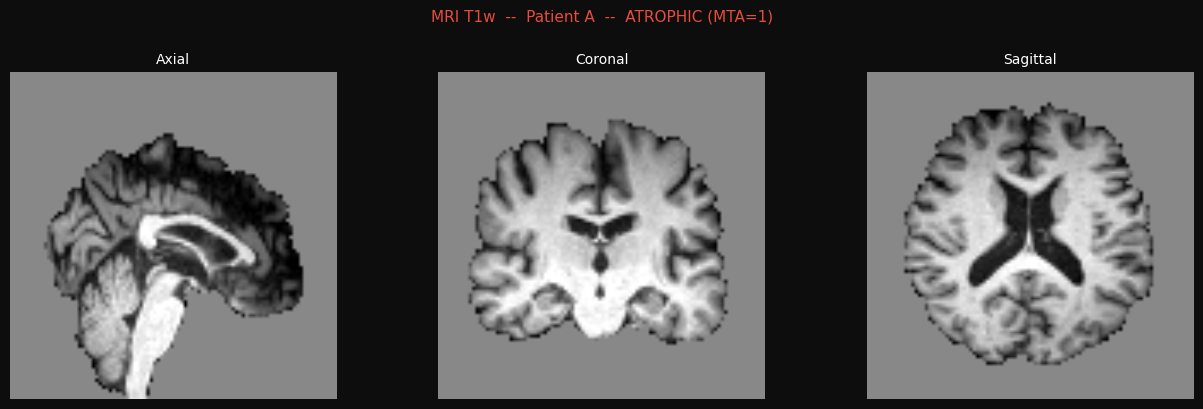


[4] PET -- 7-fold amyloid ensemble ...
    POSITIVE (A+)  (prob=0.904  thr=0.503)


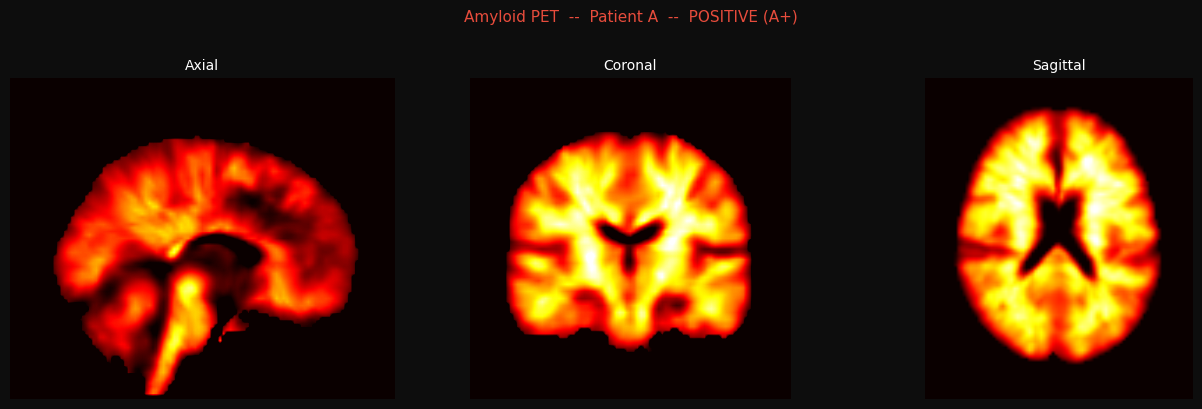


[5] Complete Patient Record (clinical + imaging features):


,MMSCORE,MOCA,FAQ,FAQFORM,FAQFINAN,FAQMEAL,FAQEVENT,DIGFOR,DIGBACK,CUBE,...,MHPSYCH,MH2NEURL,MH16SMOK,MH17MALI,MH18SURG,KEYMED,CMMED,BSXSYMNO,AMYLOID_STATUS,MTA_ATROPHY
0,27,None,3,1,1,None,None,None,None,None,...,None,None,2,None,None,0,Atorvastatine; Paracétamol; Vitamine E; Atorva...,None,1,1



[6] Diagnosis Predictions:


,LightGBM (93% F1),Neural Ensemble (~90% F1),MMSCORE,MOCA,FAQ,MH4CARD,MH9ENDO,AMYLOID_STATUS,MTA_ATROPHY
0,MCI,MCI,27,None,3,1,None,1,1


    LightGBM        -> MCI  MCI=0.952  CN=0.047  Dementia=0.001
    Neural Ensemble -> MCI  MCI=0.863  Dementia=0.094  CN=0.043

[7] Stability Predictions:


,Model,Prediction,MCI converting,CN,MCI stable
0,RNN (83% acc),MCI converting,0.561,0.383,0.056
1,LightGBM,CN,0.107,0.691,0.202



  Patient B  (/kaggle/input/datasets/baraafzlalagui/demo-fyp-data-and-models/demo fyp/patients/patient_mci_unstable/)

[1] OCR -- reading scanned report pages ...
  Found 3 page(s): ['unstable_0001.jpg', 'unstable_0002.jpg', 'unstable_0003.jpg']
  Page 1/3: unstable_0001.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done
  Page 2/3: unstable_0002.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


In [ ]:
# -- Full end-to-end pipeline for both patients --
import nibabel as nib

# Pre-load imaging volumes only for patients that have scan data
print("Pre-loading imaging volumes ...")
_mri_vols, _pet_vols = {}, {}
for _p in PATIENTS:
    if _p["mri_sub"] and _p["mri_sub"] not in _mri_vols:
        _mri_vols[_p["mri_sub"]] = np.load(MRI_IMAGE_DIR / f"{_p['mri_sub']}.npy").astype(np.float32)
    if _p["pet_sub"] and _p["pet_sub"] not in _pet_vols:
        _pet_vols[_p["pet_sub"]] = nib.load(str(PET_IMAGE_DIR / f"{_p['pet_sub']}.nii")).get_fdata(dtype=np.float32)
print(f"  {len(_mri_vols)} MRI volume(s), {len(_pet_vols)} PET volume(s) loaded.")

all_results = {}

_KEY_COLS = ["MMSCORE", "MOCA", "FAQ",
             "FAQFORM", "FAQFINAN", "FAQMEAL", "FAQEVENT",
             "DIGFOR", "DIGBACK", "CUBE", "CLOCKCON", "CLOCKNO", "CLOCKHAN", "FFLUENCY",
             "MOTHDEM", "MOTHAD", "FATHDEM", "FATHAD", "SIBDEMENT",
             "MH4CARD", "MH9ENDO", "MHPSYCH", "MH2NEURL", "MH16SMOK",
             "MH17MALI", "MH18SURG", "KEYMED", "CMMED", "BSXSYMNO"]

for pat in PATIENTS:
    label       = pat["label"]
    folder      = pat["folder"]
    mri_sub     = pat["mri_sub"]
    pet_sub     = pat["pet_sub"]
    has_imaging = mri_sub is not None

    sep = "=" * 72
    print(f"\n{sep}")
    print(f"  {label}  ({folder}/)")
    print(sep)

    # ── 1. OCR ───────────────────────────────────────────────────────────────
    print("\n[1] OCR -- reading scanned report pages ...")
    ocr_raw     = ocr_report(folder)
    ocr_cleaned = postprocess_plain_text(ocr_raw)
    print(f"    Cleaned text: {len(ocr_cleaned)} characters")

    # ── 2. LLM feature extraction ─────────────────────────────────────────────
    print("\n[2] Mistral -- extracting ADNI clinical features ...")
    llm_features = call_mistral(ocr_cleaned)
    n_found = sum(1 for v in llm_features.values() if v is not None)
    print(f"    {n_found} / {len(TARGET_COLUMNS)} fields extracted from report")

    # Extract demographics for imaging demographic fusion branches
    _age    = float(llm_features.get("age")      or 0.0)
    _ptg    = llm_features.get("PTGENDER")  # 1=Male, 2=Female (ADNI standard)
    _edu    = float(llm_features.get("PTEDUCAT") or 0.0)
    _gender_mri = 1.0 if _ptg == 1 else 0.0  # MRI training convention: M=1.0, F=0.0
    _sex_f_pet  = 0.0 if _ptg == 1 else 1.0  # PET training convention: F=1.0, M=0.0

    _feats_disp = {c: llm_features.get(c) for c in _KEY_COLS}
    print("\n    Extracted Clinical Features:")
    _df_feats = pd.DataFrame([_feats_disp])
    try:
        display(_df_feats)
    except NameError:
        print(_df_feats.to_string())

    # ── 3. MRI inference ─────────────────────────────────────────────────────
    if has_imaging:
        print("\n[3] MRI -- 7-fold atrophy ensemble ...")
        mri_atrophy, mri_avg, mri_thr = infer_mri(_mri_vols[mri_sub], _age, _gender_mri, _edu)
        mri_label = "ATROPHIC (MTA=1)" if mri_atrophy else "Healthy (MTA=0)"
        print(f"    {mri_label}  (prob={mri_avg:.3f}  thr={mri_thr:.3f})")

        vol = _mri_vols[mri_sub]
        mid = [s // 2 for s in vol.shape]
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor="#0d0d0d")
        for ax, (slc, ttl) in zip(axes, [
            (vol[mid[0], :, :], "Axial"),
            (vol[:, mid[1], :], "Coronal"),
            (vol[:, :, mid[2]], "Sagittal"),
        ]):
            ax.imshow(np.rot90(slc), cmap="gray", interpolation="bilinear")
            ax.set_title(ttl, color="white", fontsize=10)
            ax.axis("off")
        col_mri = "#e74c3c" if mri_atrophy else "#2ecc71"
        fig.suptitle(f"MRI T1w  --  {label}  --  {mri_label}", color=col_mri, fontsize=11, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        print("\n[3] MRI -- no scan for this patient  (MTA_ATROPHY set to 0)")
        mri_atrophy, mri_avg, mri_thr = 0, 0.0, 0.5

    # ── 4. PET inference ─────────────────────────────────────────────────────
    if has_imaging:
        print("\n[4] PET -- 7-fold amyloid ensemble ...")
        amyloid_status, pet_avg, pet_thr = infer_pet(_pet_vols[pet_sub], _age, _sex_f_pet)
        pet_label = "POSITIVE (A+)" if amyloid_status else "Negative (A-)"
        print(f"    {pet_label}  (prob={pet_avg:.3f}  thr={pet_thr:.3f})")

        pvol = _pet_vols[pet_sub]
        pmid = [s // 2 for s in pvol.shape]
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor="#0d0d0d")
        for ax, (slc, ttl) in zip(axes, [
            (pvol[pmid[0], :, :], "Axial"),
            (pvol[:, pmid[1], :], "Coronal"),
            (pvol[:, :, pmid[2]], "Sagittal"),
        ]):
            ax.imshow(np.rot90(slc), cmap="hot", interpolation="bilinear", vmin=0.5, vmax=2.5)
            ax.set_title(ttl, color="white", fontsize=10)
            ax.axis("off")
        col_pet = "#e74c3c" if amyloid_status else "#2ecc71"
        fig.suptitle(f"Amyloid PET  --  {label}  --  {pet_label}", color=col_pet, fontsize=11, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        print("\n[4] PET -- no scan for this patient  (AMYLOID_STATUS set to 0)")
        amyloid_status, pet_avg, pet_thr = 0, 0.0, 0.5

    # ── 5. Build complete patient record ──────────────────────────────────────
    patient_record = build_patient_record(llm_features, mri_atrophy, amyloid_status)

    _rec_cols = _KEY_COLS + ["AMYLOID_STATUS", "MTA_ATROPHY"]
    _rec_disp = {c: patient_record.get(c) for c in _rec_cols}
    print("\n[5] Complete Patient Record (clinical + imaging features):")
    _df_record = pd.DataFrame([_rec_disp])
    try:
        display(_df_record)
    except NameError:
        print(_df_record.to_string())

    # ── 6. Diagnosis classification ───────────────────────────────────────────
    diag_lgb = predict_diagnosis(patient_record, diag_arts)
    diag_ens = predict_diag_ensemble(patient_record, diag_arts, diag_neural_models)

    _df_diag = _df_record[["MMSCORE", "MOCA", "FAQ", "MH4CARD", "MH9ENDO",
                            "AMYLOID_STATUS", "MTA_ATROPHY"]].copy()
    _df_diag.insert(0, "LightGBM (93% F1)",        diag_lgb["prediction"])
    _df_diag.insert(1, "Neural Ensemble (~90% F1)", diag_ens["prediction"])

    d_lgb_s = sorted(diag_lgb["probabilities"].items(), key=lambda x: -x[1])
    d_ens_s = sorted(diag_ens["probabilities"].items(), key=lambda x: -x[1])
    print("\n[6] Diagnosis Predictions:")
    try:
        display(_df_diag)
    except NameError:
        print(_df_diag.to_string())
    print("    LightGBM        -> " + diag_lgb["prediction"] + "  "
          + "  ".join(f"{k}={v:.3f}" for k, v in d_lgb_s))
    print("    Neural Ensemble -> " + diag_ens["prediction"] + "  "
          + "  ".join(f"{k}={v:.3f}" for k, v in d_ens_s))

    # ── 7. Stability classification ───────────────────────────────────────────
    visits   = build_visits(patient_record, amyloid_status, mri_atrophy)
    stab_rnn = predict_stability(visits, stab_arts, stab_model)
    stab_lgb = predict_stab_lightgbm(visits, stab_arts)
    s_rnn_s  = sorted(stab_rnn["probabilities"].items(), key=lambda x: -x[1])
    s_lgb_s  = sorted(stab_lgb["probabilities"].items(), key=lambda x: -x[1])

    _stab_rows = [
        {"Model": "RNN (83% acc)", "Prediction": stab_rnn["prediction"].replace("_", " "),
         **{k.replace("_", " "): f"{v:.3f}" for k, v in s_rnn_s}},
        {"Model": "LightGBM",     "Prediction": stab_lgb["prediction"].replace("_", " "),
         **{k.replace("_", " "): f"{v:.3f}" for k, v in s_lgb_s}},
    ]
    print("\n[7] Stability Predictions:")
    _df_stab = pd.DataFrame(_stab_rows)
    try:
        display(_df_stab)
    except NameError:
        print(_df_stab.to_string())

    # ── Store results ─────────────────────────────────────────────────────────
    all_results[label] = {
        "patient_record": patient_record,
        "mri_atrophy":    mri_atrophy,    "mri_avg": mri_avg,  "mri_thr": mri_thr,
        "amyloid_status": amyloid_status, "pet_avg": pet_avg,  "pet_thr": pet_thr,
        "diag_lgb":       diag_lgb,
        "diag_ens":       diag_ens,
        "stab_rnn":       stab_rnn,
        "stab_lgb":       stab_lgb,
    }

print(f"\n{'='*72}")
print("  Both patients processed.  Run the summary cell.")
print(f"{'='*72}")


## Final Results — All Models, Both Patients

Renders the side-by-side comparison panel for both patients showing:
MRI atrophy, PET amyloid, key clinical scores, and the predictions from
all four models (LightGBM diagnosis, Neural Ensemble diagnosis,
RNN stability, LightGBM stability). Also saves `demo_comparison.png`.

In [ ]:
# -- Side-by-side comparison: both patients, all models --
n_pat = len(all_results)
fig   = plt.figure(figsize=(18, 8 * n_pat), facecolor='#111111')
gs    = gridspec.GridSpec(n_pat * 2, 4, figure=fig, hspace=0.65, wspace=0.35)

COLOR_OK   = "#2ecc71"
COLOR_BAD  = "#e74c3c"
COLOR_WARN = "#f39c12"
COLOR_NEU  = "#3498db"
COLOR_PRP  = "#9b59b6"


def add_result_box(ax, title, value, subtitle="", color=COLOR_NEU):
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.add_patch(plt.Rectangle((0.03, 0.03), 0.94, 0.94, fill=False,
                                edgecolor=color, linewidth=2.5, transform=ax.transAxes))
    ax.text(0.5, 0.84, title, ha='center', va='center', fontsize=8,
            color='#aaaaaa', transform=ax.transAxes)
    ax.text(0.5, 0.52, value, ha='center', va='center', fontsize=13,
            color=color, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.18, subtitle, ha='center', va='center', fontsize=7,
            color='#888888', transform=ax.transAxes, wrap=True)


for row_i, (label, res) in enumerate(all_results.items()):
    pr      = res["patient_record"]
    mri_a   = res["mri_atrophy"];    m_avg = res["mri_avg"]; m_thr = res["mri_thr"]
    amy     = res["amyloid_status"]; p_avg = res["pet_avg"]; p_thr = res["pet_thr"]
    d_lgb   = res["diag_lgb"];   d_ens = res["diag_ens"]
    s_rnn   = res["stab_rnn"];   s_lgb = res["stab_lgb"]
    base    = row_i * 2

    # Row 0: MRI | PET | Clinical summary
    ax_mri = fig.add_subplot(gs[base, 0])
    add_result_box(ax_mri, "MRI Atrophy",
                   "ATROPHIC" if mri_a else "HEALTHY",
                   f"prob={m_avg:.3f}  thr={m_thr:.3f}",
                   COLOR_BAD if mri_a else COLOR_OK)

    ax_pet = fig.add_subplot(gs[base, 1])
    add_result_box(ax_pet, "PET Amyloid",
                   "POSITIVE" if amy else "NEGATIVE",
                   f"prob={p_avg:.3f}  thr={p_thr:.3f}",
                   COLOR_BAD if amy else COLOR_OK)

    ax_clin = fig.add_subplot(gs[base, 2:])
    ax_clin.set_facecolor('#1a1a2e'); ax_clin.axis('off')
    _mmse = float(pr.get("MMSCORE") or 0)
    _moca = float(pr.get("MOCA")    or 0)
    _faq  = float(pr.get("FAQ")     or 0)
    _mh4  = float(pr.get("MH4CARD") or 0)
    _mh9  = float(pr.get("MH9ENDO") or 0)
    _mhps = float(pr.get("MHPSYCH") or 0)
    clinical_items = [
        ("MMSE",     _mmse, 30, 24,  "/ 30", True),
        ("MoCA",     _moca, 30, 26,  "/ 30", True),
        ("FAQ",      _faq,  30,  5,  "/ 30", False),
        ("HTA",      _mh4,   1, 0.5, "flag", False),
        ("Diabetes", _mh9,   1, 0.5, "flag", False),
        ("Psych.",   _mhps,  1, 0.5, "flag", False),
    ]
    ax_clin.text(0.5, 0.97, f"Key Clinical Summary -- {label}", ha='center', va='top',
                 color='white', fontsize=10, fontweight='bold', transform=ax_clin.transAxes)
    for i, (name, val, max_v, thr, unit, low_bad) in enumerate(clinical_items):
        y = 0.80 - i * 0.128
        abnormal = (val < thr) if low_bad else (val > thr)
        c = COLOR_BAD if abnormal else COLOR_OK
        frac = min(val / max_v, 1.0) if max_v else 0
        ax_clin.barh(y, frac, height=0.07, left=0.22, color=c, alpha=0.7,
                     transform=ax_clin.transAxes)
        ax_clin.text(0.21, y + 0.035, f"{name:8s}", ha='right', va='center',
                     color='#aaaaaa', fontsize=8.5, transform=ax_clin.transAxes)
        lbl = ("present" if val >= 1 else "absent") if unit == "flag" else f"{val:.1f}  {unit}"
        ax_clin.text(0.22 + frac + 0.01, y + 0.035, lbl, ha='left', va='center',
                     color=c, fontsize=8.5, transform=ax_clin.transAxes)

    # Row 1: 4 prediction boxes
    def _pred_col(pred, mapping):
        return mapping.get(pred, COLOR_NEU)

    diag_map = {"MCI": COLOR_WARN, "CN": COLOR_OK, "Dementia": COLOR_BAD}
    stab_map = {"MCI_converting": COLOR_BAD, "CN": COLOR_OK, "MCI_stable": COLOR_WARN}

    # Diagnosis LightGBM
    ax0 = fig.add_subplot(gs[base + 1, 0])
    d0s = sorted(d_lgb["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax0, "DIAGNOSIS\nLightGBM (93% F1)",
                   d_lgb["prediction"],
                   " | ".join(f"{c}: {p:.2f}" for c, p in d0s),
                   _pred_col(d_lgb["prediction"], diag_map))

    # Diagnosis Neural Ensemble
    ax1 = fig.add_subplot(gs[base + 1, 1])
    d1s = sorted(d_ens["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax1, "DIAGNOSIS\nNeural Ensemble (~90% F1)",
                   d_ens["prediction"],
                   " | ".join(f"{c}: {p:.2f}" for c, p in d1s),
                   _pred_col(d_ens["prediction"], diag_map))

    # Stability RNN
    ax2 = fig.add_subplot(gs[base + 1, 2])
    s0s = sorted(s_rnn["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax2, "STABILITY\nRNN (83% acc)",
                   s_rnn["prediction"].replace("_", " "),
                   " | ".join(f"{c.replace('_',' ')}: {p:.2f}" for c, p in s0s),
                   _pred_col(s_rnn["prediction"], stab_map))

    # Stability LightGBM
    ax3 = fig.add_subplot(gs[base + 1, 3])
    s1s = sorted(s_lgb["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax3, "STABILITY\nLightGBM",
                   s_lgb["prediction"].replace("_", " "),
                   " | ".join(f"{c.replace('_',' ')}: {p:.2f}" for c, p in s1s),
                   _pred_col(s_lgb["prediction"], stab_map))

    # Text summary
    age_d = pr.get("age") or "N/A"; sex_d = pr.get("PTGENDER") or "N/A"
    print(f"\n{'='*68}")
    print(f"  {label}  (Age: {age_d}, Sex: {sex_d})")
    print(f"{'='*68}")
    print(f"  MRI           -> {'Atrophic (MTA=1)' if mri_a else 'Healthy (MTA=0)'}")
    print(f"  PET           -> {'Amyloid POSITIVE (A+)' if amy else 'Amyloid NEGATIVE (A-)'}")
    print(f"  DIAG LightGBM -> {d_lgb['prediction']}  "
          f"(p={max(p for _,p in d0s):.3f})")
    print(f"  DIAG Ensemble -> {d_ens['prediction']}  "
          f"(p={max(p for _,p in d1s):.3f})"
          f"  members={d_ens['ensemble_members']}")
    print(f"  STAB RNN      -> {s_rnn['prediction']}  "
          f"(p={max(p for _,p in s0s):.3f})")
    print(f"  STAB LightGBM -> {s_lgb['prediction']}  "
          f"(p={max(p for _,p in s1s):.3f})")

fig.suptitle("MULTIMODAL MCI PREDICTION -- PATIENT COMPARISON (ALL MODELS)",
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.savefig("demo_comparison.png", dpi=120, bbox_inches='tight', facecolor='#111111')
plt.show()
